### General Results of the optimisation

In [78]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from IPython.display import display, Markdown
import config
import importlib
importlib.reload(config)

# Get latest run
RESULTS_ROOT = Path("02-MODEL-RESULTS")
latest_run = sorted([d for d in RESULTS_ROOT.iterdir() if d.is_dir()])[-1]

# Load summary and settings
with open(latest_run / "results_summary.json", "r") as f:
    summary = json.load(f)
with open(latest_run / "settings_snapshot.json", "r") as f:
    settings = json.load(f)
active_parameters = settings.get("parameters", {})

# Load time series
df = pd.read_csv(latest_run / "timeseries_results.csv", parse_dates=['timestamp'])
df_soc = df.copy()
df_compare = pd.read_csv(latest_run / "baseline_vs_optimized.csv")
df_peak_metrics = pd.read_csv(latest_run / "peak_metrics.csv")
df_top_peaks = pd.read_csv(latest_run / "top_peak_intervals.csv", parse_dates=['timestamp'])
timestep_hours = pd.Series(pd.to_datetime(df["timestamp"])).diff().dropna().dt.total_seconds().median() / 3600 if "timestamp" in df.columns and len(df) > 1 else 0.25
monthly_summary_path = latest_run / "monthly_summary.csv"

# 1. Dynamic Year Extraction from the main data
# Looks at the most common year in your dataset (ignores random 2026 artifacts)
target_year = df["timestamp"].dt.year.mode()[0] 

if monthly_summary_path.exists():
    df_monthly = pd.read_csv(monthly_summary_path)
    # Ensure it's treated as a datetime/period for proper sorting if loaded from CSV
    df_monthly["month"] = pd.to_datetime(df_monthly["month"]).dt.to_period("M")
else:
    df_m = df.copy()
    # KEEP it as a period object here (do NOT cast to .astype(str) yet)
    df_m["month"] = df_m["timestamp"].dt.to_period("M")
    
    # Calculate costs and revenue per timestep
    df_m["baseline_import_cost"] = df_m["baseline_grid_import"] * df_m["import_price_with_grid"] * 0.25
    df_m["optimized_import_cost"] = df_m["grid_flow"] * df_m["import_price_with_grid"] * 0.25
    
    if "grid_export" in df_m.columns and "export_price" in df_m.columns:
        df_m["monthly_export_revenue_raw"] = df_m["grid_export"] * df_m["export_price"] * 0.25
    else:
        df_m["monthly_export_revenue_raw"] = 0.0

    # Aggregate by month
    df_monthly = df_m.groupby("month", as_index=False).agg(
        monthly_import_cost_before=("baseline_import_cost", "sum"),
        monthly_import_cost_after=("optimized_import_cost", "sum"),
        monthly_export_revenue=("monthly_export_revenue_raw", "sum"),
        monthly_peak_before=("baseline_grid_import", "max"),
        monthly_peak_after=("grid_flow", "max"),
    )

# --- MOVED OUTSIDE: These columns must be calculated every time ---
peak_price_per_kw = active_parameters.get("peak_shaving_cost_factor", 0.0)

# Calculate Energy Savings
df_monthly["energy_import_savings"] = (
    df_monthly["monthly_import_cost_before"] - df_monthly["monthly_import_cost_after"]
)

# Calculate Peak Cost Savings using annual baseline and optimized peak demand costs
baseline_peak_cost = float(summary.get("no_battery_peak_demand_cost", np.nan))
optimized_peak_cost = float(summary.get("peak_demand_cost", np.nan))
monthly_peak_savings_value = np.nan
if np.isfinite(baseline_peak_cost) and np.isfinite(optimized_peak_cost):
    monthly_peak_savings_value = (baseline_peak_cost - optimized_peak_cost) / 12.0

df_monthly["peak_shaving_savings"] = monthly_peak_savings_value
# Keep a dedicated column for the equally allocated monthly peak savings
df_monthly["monthly_peak_cost_savings"] = monthly_peak_savings_value
# Import the annual baseline/optimized peak costs so the notebook can display them
df_monthly["annual_baseline_peak_cost"] = baseline_peak_cost
df_monthly["annual_optimized_peak_cost"] = optimized_peak_cost

df_monthly["monthly_savings"] = df_monthly["energy_import_savings"]
df_monthly["monthly_peak_reduction"] = df_monthly["monthly_peak_before"] - df_monthly["monthly_peak_after"]
df_monthly["monthly_total_benefit"] = (
    df_monthly["energy_import_savings"] + 
    df_monthly["peak_shaving_savings"] + 
    df_monthly["monthly_export_revenue"]
)

# 2. Dynamic Filtering & Guaranteed Sorting
# Filter for the target year dynamically
df_monthly = df_monthly[df_monthly["month"].dt.year == target_year]

# Sort chronologically (Jan -> Dec)
df_monthly = df_monthly.sort_values("month").reset_index(drop=True)

# 3. Clean string conversion FOR PLOTTING ONLY
# This converts '2025-01' to just '01' (or 'Jan') safely after sorting
df_monthly["month_label"] = df_monthly["month"].dt.strftime("%m") # "01", "02", etc.
# df_monthly["month_label"] = df_monthly["month"].dt.strftime("%b") # Optional: "Jan", "Feb"


weekly_summary_path = latest_run / "weekly_summary.csv"
if weekly_summary_path.exists():
    df_weekly = pd.read_csv(weekly_summary_path)
else:
    df_weekly = pd.DataFrame(
        columns=[
            "week_start",
            "weekly_import_energy_before_kwh",
            "weekly_import_energy_after_kwh",
            "weekly_energy_savings_kwh",
            "weekly_import_cost_before",
            "weekly_import_cost_after",
            "weekly_cost_savings",
            "weekly_peak_before",
            "weekly_peak_after",
            "weekly_peak_reduction",
        ]
    )
battery_utilization_path = latest_run / "battery_utilization_summary.csv"
if battery_utilization_path.exists():
    df_battery_util = pd.read_csv(battery_utilization_path)
elif {"battery_soc", "battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    installed_capacity = summary.get("battery_capacity_kwh", 0.0)
    avg_soc = df["battery_soc"].mean()
    min_soc = df["battery_soc"].min()
    max_soc = df["battery_soc"].max()
    discharged_energy = df["battery_discharge_power"].sum() * timestep_hours
    charged_energy = df["battery_charge_power"].sum() * timestep_hours
    equivalent_cycles = discharged_energy / installed_capacity if installed_capacity else float("nan")
    df_battery_util = pd.DataFrame([
        {"Metric": "Charged energy", "Value": charged_energy, "Unit": "kWh/year"},
        {"Metric": "Discharged energy", "Value": discharged_energy, "Unit": "kWh/year"},
        {"Metric": "Equivalent full cycles", "Value": equivalent_cycles, "Unit": "cycles/year"},
        {"Metric": "Average state of charge", "Value": avg_soc, "Unit": "kWh"},
        {"Metric": "Minimum state of charge", "Value": min_soc, "Unit": "kWh"},
        {"Metric": "Maximum state of charge", "Value": max_soc, "Unit": "kWh"},
        {"Metric": "Hours near empty (<=10%)", "Value": (df["battery_soc"] <= 0.10 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Hours near full (>=90%)", "Value": (df["battery_soc"] >= 0.90 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Maximum charge power used", "Value": df["battery_charge_power"].max(), "Unit": "kW"},
        {"Metric": "Maximum discharge power used", "Value": df["battery_discharge_power"].max(), "Unit": "kW"},
    ])
else:
    df_battery_util = pd.DataFrame(columns=["Metric", "Value", "Unit"])
battery_sensitivity_path = latest_run / "battery_size_sensitivity.csv"
if battery_sensitivity_path.exists():
    df_battery_sensitivity = pd.read_csv(battery_sensitivity_path)
else:
    df_battery_sensitivity = pd.DataFrame(columns=["battery_size_kwh", "objective_total_cost", "import_cost", "peak_demand_cost", "annualized_battery_cost", "annual_savings", "npv", "irr", "payback_years", "discounted_payback_years", "status"])
df_fin = pd.read_csv(latest_run / "financial_cashflows.csv")

if "import_price_with_grid" not in df.columns:
    # If missing, fallback to electricity_price or 0.0
    df["import_price_with_grid"] = df.get("import_price", df.get("electricity_price", 0.0))

if "export_price" not in df.columns:
    # If missing, fallback to electricity_price or 0.0
    df["export_price"] = df.get("export_price", df.get("electricity_price", 0.0))

# Existing checks for flows
for required_col in ["pv_flow", "grid_flow", "battery_charge_power", "battery_discharge_power", "total_load"]:
    if required_col not in df.columns:
        df[required_col] = 0.0

if "spill_flow" not in df.columns:
    df["spill_flow"] = 0.0

if "grid_export" not in df.columns:
    df["grid_export"] = 0.0

def infer_timestep_hours(timestamp_series, default_hours=0.25):
    if timestamp_series is None or len(timestamp_series) < 2:
        return default_hours
    deltas = pd.Series(pd.to_datetime(timestamp_series)).diff().dropna()
    if deltas.empty:
        return default_hours
    step_hours = deltas.dt.total_seconds().median() / 3600
    return float(step_hours) if step_hours > 0 else default_hours

def format_duration(hours_value):
    if pd.isna(hours_value):
        return "-"
    hours_value = float(hours_value)
    abs_value = abs(hours_value)
    if abs_value < 1:
        return f"{hours_value * 60:,.0f} min"
    if abs_value < 48:
        return f"{hours_value:,.0f} h"
    if abs_value < 24 * 21:
        return f"{hours_value / 24:,.1f} d"
    return f"{hours_value / (24 * 7):,.1f} w"

def duration_tick_formatter(value, _):
    return format_duration(value)

timestep_hours = infer_timestep_hours(df["timestamp"]) if "timestamp" in df.columns else timestep_hours

for required_col in ["pv_flow", "grid_flow", "battery_charge_power", "battery_discharge_power", "total_load"]:
    if required_col not in df.columns:
        df[required_col] = 0.0
if "spill_flow" not in df.columns:
    df["spill_flow"] = 0.0
if "grid_export" not in df.columns:
    df["grid_export"] = 0.0
if "electricity_price" not in df.columns:
    df["electricity_price"] = 0.0

run_metadata = {
    "timestamp": settings.get("timestamp"),
    "timesteps_used": settings.get("timesteps_used"),
    "load_existing_input_dict": settings.get("load_existing_input_dict"),
    "max_timesteps": settings.get("max_timesteps"),
    "debug_infeasibility": settings.get("debug_infeasibility"),
}
settings_table_df = pd.DataFrame(
    [{"Section": "Run Metadata", "Name": key, "Value": value} for key, value in run_metadata.items()]
    + [{"Section": "Model Parameter", "Name": key, "Value": value} for key, value in active_parameters.items()]
)
metric_labels = {
    "runtime_seconds": "Runtime [s]",
    "objective_total_cost": "TAC / Objective Total Cost [CHF/year]",
    "opex": "OPEX [CHF/year]",
    "import_cost": "Import Cost [CHF/year]",
    "peak_demand_cost": "Peak Demand Cost [CHF/year]",
    "fixed_om_cost": "Fixed O&M Cost [CHF/year]",
    "variable_om_cost": "Variable O&M Cost [CHF/year]",
    "total_om_cost": "Total O&M Cost [CHF/year]",
    "annualized_battery_cost": "Annualized Battery Cost [CHF/year]",
    "battery_capacity_kwh": "Battery Capacity [kWh]",
    "battery_power_capacity_kw": "Battery Power Capacity [kW]",
    "yearly_peak": "Yearly Peak Grid Import [kW]",
    "sum_monthly_peaks": "Sum Monthly Peaks [kW]",
    "monthly_peaks": "Monthly Peaks [kW]",
    "curtailed_energy_kwh": "Curtailed Energy [kWh/year]",
    "discharged_energy_kwh": "Battery Discharged Energy [kWh/year]",
    "equivalent_full_cycles": "Equivalent Full Cycles [cycles/year]",
    "no_battery_import_cost": "No-Battery Import Cost [CHF/year]",
    "no_battery_peak_demand_cost": "No-Battery Peak Demand Cost [CHF/year]",
    "no_battery_total_cost": "No-Battery Total Cost [CHF/year]",
    "annual_savings": "Annual Savings [CHF/year]",
    "annual_total_cost_reduction": "Annual Total Cost Reduction [CHF/year]",
    "investment_cost": "Initial Investment Cost [CHF]",
    "energy_investment_cost": "Energy CAPEX [CHF]",
    "power_investment_cost": "Power CAPEX [CHF]",
    "replacement_cost": "Battery Replacement Cost [CHF]",
    "replacement_year": "Battery Replacement Year",
    "replacement_basis": "Replacement Basis",
    "npv": "NPV [CHF]",
    "irr": "IRR [-]",
    "payback_years": "Payback [years]",
    "discounted_payback_years": "Discounted Payback [years]",
}

preferred_metric_order = [
    "runtime_seconds",
    "objective_total_cost",
    "opex",
    "import_cost",
    "peak_demand_cost",
    "fixed_om_cost",
    "variable_om_cost",
    "total_om_cost",
    "annualized_battery_cost",
    "battery_capacity_kwh",
    "battery_power_capacity_kw",
    "yearly_peak",
    "sum_monthly_peaks",
    "monthly_peaks",
    "curtailed_energy_kwh",
    "discharged_energy_kwh",
    "equivalent_full_cycles",
    "no_battery_import_cost",
    "no_battery_peak_demand_cost",
    "no_battery_total_cost",
    "annual_savings",
    "annual_total_cost_reduction",
    "investment_cost",
    "energy_investment_cost",
    "power_investment_cost",
    "replacement_cost",
    "replacement_year",
    "replacement_basis",
    "npv",
    "irr",
    "payback_years",
    "discounted_payback_years",
]

summary_rows = []
for key in preferred_metric_order:
    if key in summary:
        value = summary[key]
        summary_rows.append(
            {
                "Metric": metric_labels.get(key, key),
                "Value": json.dumps(value) if isinstance(value, (dict, list)) else value,
            }
        )

for key, value in summary.items():
    if key not in preferred_metric_order:
        summary_rows.append(
            {
                "Metric": metric_labels.get(key, key),
                "Value": json.dumps(value) if isinstance(value, (dict, list)) else value,
            }
        )

detailed_summary_df = pd.DataFrame(summary_rows)

dispatch_df = df.copy()
dispatch_df["week_start"] = dispatch_df["timestamp"].dt.to_period("W").apply(lambda p: p.start_time)
weekly_summary = dispatch_df.groupby("week_start", as_index=False).agg(
    total_load=("total_load", "sum"),
    total_pv=("pv_flow", "sum"),
    total_grid_import=("grid_flow", "sum"),
    total_grid_export=("grid_export", "sum"),
    total_battery_charge=("battery_charge_power", "sum"),
    total_battery_discharge=("battery_discharge_power", "sum"),
    total_curtailment=("spill_flow", "sum"),
    avg_price=("electricity_price", "mean"),
    peak_load=("total_load", "max"),
)
weekly_summary["month"] = weekly_summary["week_start"].dt.month

def _pick_week(label, candidate_df, sort_columns):
    if candidate_df.empty:
        return None
    ordered = candidate_df.sort_values(sort_columns, ascending=[False] * len(sort_columns)).iloc[0]
    return {"label": label, "week_start": ordered["week_start"]}

week_candidates = [
    _pick_week("Winter Week", weekly_summary[weekly_summary["month"].isin([12, 1, 2])], ["total_load", "peak_load"]),
    _pick_week("Summer Week", weekly_summary[weekly_summary["month"].isin([6, 7, 8])], ["total_pv", "total_load"]),
    _pick_week("Highest-Load Week", weekly_summary, ["total_load", "peak_load"]),
    _pick_week("Highest-Price Week", weekly_summary, ["avg_price", "total_grid_import"]),
    _pick_week("Highest-Curtailment Week", weekly_summary, ["total_curtailment", "total_pv"]),
]
selected_dispatch_weeks = []
seen_week_starts = set()
for candidate in week_candidates:
    if candidate is None:
        continue
    week_start = candidate["week_start"]
    if week_start in seen_week_starts:
        continue
    seen_week_starts.add(week_start)
    selected_dispatch_weeks.append(candidate)
dispatch_week_table = pd.DataFrame(selected_dispatch_weeks)

print(f"Loaded results from: {latest_run.name}")

Loaded results from: 20260603_184526_lp_35041steps


In [79]:
def format_value(v):
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if pd.isna(v):
        return "-"
    if isinstance(v, (int, float)):
        return f"{v:,.2f}"
    return v

display(Markdown("## Baseline vs Optimized Comparison"))
display(df_compare.style.format({
    "Baseline": format_value,
    "Optimized": format_value,
    "Optimized - Baseline": format_value,
}))


supplementary_kpis = [
    ("Battery energy size [kWh]", "battery_capacity_kwh"),
    ("Battery power rating [kW]", "battery_power_capacity_kw"),
    ("Annual Savings", "annual_savings"),
    ("Equivalent Full Cycles", "equivalent_full_cycles"),
    ("Replacement Basis", "replacement_basis"),
    ("Energy CAPEX [CHF]", "energy_investment_cost"),
    ("Power CAPEX [CHF]", "power_investment_cost"),
    ("Curtailed Energy (kWh)", "curtailed_energy_kwh"),
    ("Annual Peak", "yearly_peak"),
    ("Replacement Cost", "replacement_cost"),
    ("Replacement Year", "replacement_year"),
    ("IRR", "irr"),
]
kpi_df = pd.DataFrame([
    {"Metric": label, "Value": summary.get(key)}
    for label, key in supplementary_kpis
])

display(Markdown("## Supplementary KPIs"))
display(kpi_df.style.format({"Value": format_value}))

display(Markdown("## Run and Model Settings"))
display(settings_table_df.style.format({"Value": format_value}))

## Baseline vs Optimized Comparison

,Metric,Baseline,Optimized,Optimized - Baseline,Unit
0,Battery size,0.00,"1,722.53","1,722.53",kWh
1,Battery power rating,0.00,690.89,690.89,kW
2,Annual import cost,"548,041.23","499,169.47","-48,871.77",CHF/year
3,Total annual cost,"583,860.87","556,553.07","-27,307.81",CHF/year
4,Annual peak-demand cost,"35,819.64","23,383.56","-12,436.08",CHF/year
5,Annual import cost savings,0.00,"48,871.77","48,871.77",CHF/year
6,Annual total cost reduction,0.00,"27,307.81","27,307.81",CHF/year
7,CAPEX,0.00,"482,683.85","482,683.85",CHF
8,CAPEX energy component,0.00,"344,505.21","344,505.21",CHF
9,CAPEX power component,0.00,"138,178.64","138,178.64",CHF


## Supplementary KPIs

,Metric,Value
0,Battery energy size [kWh],"1,722.53"
1,Battery power rating [kW],690.89
2,Annual Savings,"62,374.26"
3,Equivalent Full Cycles,195.83
4,Replacement Basis,calendar_life
5,Energy CAPEX [CHF],"344,505.21"
6,Power CAPEX [CHF],"138,178.64"
7,Curtailed Energy (kWh),-
8,Annual Peak,"1,299.09"
9,Replacement Cost,"386,147.08"


## Run and Model Settings

,Section,Name,Value
0,Run Metadata,timestamp,2026-06-03T18:48:17
1,Run Metadata,timesteps_used,"35,041.00"
2,Run Metadata,load_existing_input_dict,No
3,Run Metadata,max_timesteps,-
4,Run Metadata,debug_infeasibility,No
5,Model Parameter,PV_max_capacity,"10,000.00"
6,Model Parameter,Battery_max_inflow,"1,000.00"
7,Model Parameter,Battery_max_outflow,"1,000.00"
8,Model Parameter,Battery_max_capacity,"100,000.00"
9,Model Parameter,Battery_eta_charge,0.90


In [80]:
display(Markdown("## Peak Import Before vs After Battery"))
display(df_peak_metrics.style.format({
    "Before battery": format_value,
    "After battery": format_value,
    "Reduction": format_value,
    "Reduction %": format_value,
}))

display(Markdown("### Top 10 Peak Intervals Reduced"))
display(df_top_peaks.head(10).style.format({
    "baseline_grid_import": format_value,
    "optimized_grid_import": format_value,
    "peak_reduction": format_value,
}))

## Peak Import Before vs After Battery

,Metric,Before battery,After battery,Reduction,Reduction %,Unit
0,Maximum grid import,"1,989.98","1,299.09",690.89,34.72,kW
1,95th percentile grid import,"1,068.86","1,068.68",0.18,0.02,kW


### Top 10 Peak Intervals Reduced

,timestamp,baseline_grid_import,optimized_grid_import,peak_reduction
0,2025-02-27 19:15:00,956.72,265.83,690.89
1,2025-04-29 19:15:00,775.32,84.43,690.89
2,2025-07-30 19:15:00,749.66,58.77,690.89
3,2025-02-17 05:30:00,"1,681.26",990.37,690.89
4,2025-08-06 19:15:00,763.42,72.53,690.89
5,2025-07-28 20:15:00,977.44,286.55,690.89
6,2025-07-10 19:30:00,692.48,1.59,690.89
7,2025-08-22 20:30:00,"1,022.12",331.23,690.89
8,2025-05-09 19:15:00,743.66,52.77,690.89
9,2025-04-14 20:30:00,960.28,269.39,690.89


## Grid Import Duration Curve

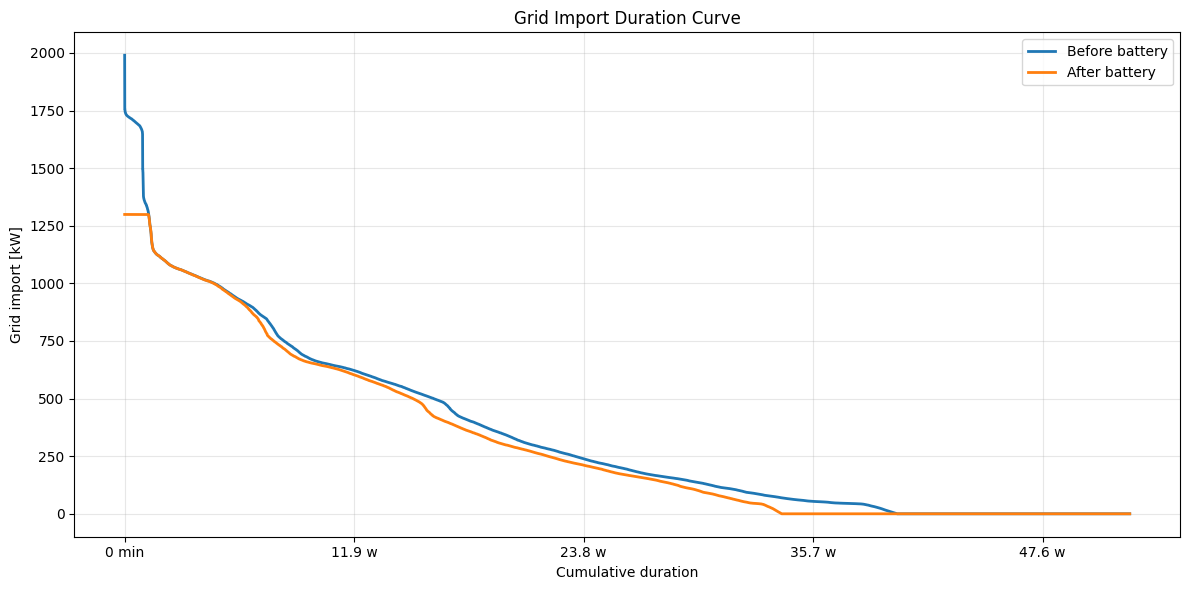

In [81]:
display(Markdown("## Grid Import Duration Curve"))

baseline_duration = df["baseline_grid_import"].sort_values(ascending=False).reset_index(drop=True)
optimized_duration = df["grid_flow"].sort_values(ascending=False).reset_index(drop=True)
duration_axis_hours = pd.Series(np.arange(1, len(baseline_duration) + 1) * timestep_hours)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(duration_axis_hours, baseline_duration, label="Before battery", linewidth=2)
ax.plot(duration_axis_hours, optimized_duration, label="After battery", linewidth=2)
ax.set_xlabel("Cumulative duration")
ax.set_ylabel("Grid import [kW]")
ax.set_title("Grid Import Duration Curve")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(duration_tick_formatter))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

plt.savefig(latest_run / f"grid_import_duration_curve_spot_year_{config.Spot_price_year}.png", dpi=300)
plt.show()

In [82]:
display(Markdown("## Monthly Savings and Peak Reduction"))
display(df_monthly.style.format({
    "monthly_import_cost_before": format_value,
    "monthly_import_cost_after": format_value,
    "monthly_savings": format_value,
    "monthly_peak_cost_savings": format_value,
    "annual_baseline_peak_cost": format_value,
    "annual_optimized_peak_cost": format_value,
    "monthly_peak_before": format_value,
    "monthly_peak_after": format_value,
    "monthly_peak_reduction": format_value,
}))

display(Markdown("## Weekly Savings and Peak Reduction"))
if df_weekly.empty:
    display(Markdown("_Run the model again to generate `weekly_summary.csv` for this section._"))
else:
    display(df_weekly.style.format({
        "weekly_import_energy_before_kwh": format_value,
        "weekly_import_energy_after_kwh": format_value,
        "weekly_energy_savings_kwh": format_value,
        "weekly_import_cost_before": format_value,
        "weekly_import_cost_after": format_value,
        "weekly_cost_savings": format_value,
        "weekly_peak_before": format_value,
        "weekly_peak_after": format_value,
        "weekly_peak_reduction": format_value,
    }))

## Monthly Savings and Peak Reduction

,month,monthly_import_cost_before,monthly_import_cost_after,monthly_peak_before,monthly_peak_after,monthly_export_revenue,monthly_savings,monthly_peak_reduction,monthly_total_benefit,energy_import_savings,peak_shaving_savings,monthly_peak_cost_savings,annual_baseline_peak_cost,annual_optimized_peak_cost,month_label
0,2025-01,"60,696.15","60,890.97","1,756.38","1,299.09",0.000000,-194.82,457.29,841.523020,-194.816766,1036.339785,"1,036.34","35,819.64","23,383.56",01
1,2025-02,"45,090.47","39,737.71","1,746.74","1,299.09",456.875937,"5,352.76",447.65,6845.977885,5352.762163,1036.339785,"1,036.34","35,819.64","23,383.56",02
2,2025-03,"42,869.34","35,685.15","1,757.86","1,299.09",1989.679212,"7,184.19",458.77,10210.208149,7184.189152,1036.339785,"1,036.34","35,819.64","23,383.56",03
3,2025-04,"36,173.28","29,902.83","1,139.16","1,139.16",3255.292088,"6,270.45",0.00,10562.083524,6270.451650,1036.339785,"1,036.34","35,819.64","23,383.56",04
4,2025-05,"37,087.38","32,089.18","1,136.90","1,136.90",2885.469441,"4,998.20",0.00,8920.005428,4998.196202,1036.339785,"1,036.34","35,819.64","23,383.56",05
5,2025-06,"40,800.44","39,546.78","1,088.54","1,088.54",205.034874,"1,253.66",-0.00,2495.038988,1253.664329,1036.339785,"1,036.34","35,819.64","23,383.56",06
6,2025-07,"37,721.81","30,926.03","1,143.16","1,143.16",1066.310562,"6,795.78",0.00,8898.430403,6795.780056,1036.339785,"1,036.34","35,819.64","23,383.56",07
7,2025-08,"37,231.48","31,579.71","1,989.98","1,299.09",786.025400,"5,651.77",690.89,7474.137656,5651.772471,1036.339785,"1,036.34","35,819.64","23,383.56",08
8,2025-09,"41,612.52","36,024.23","1,291.82","1,291.82",333.176945,"5,588.29",0.00,6957.807312,5588.290582,1036.339785,"1,036.34","35,819.64","23,383.56",09
9,2025-10,"54,481.48","50,537.91","1,762.42","1,299.09",83.692291,"3,943.57",463.33,5063.601886,3943.569809,1036.339785,"1,036.34","35,819.64","23,383.56",10


## Weekly Savings and Peak Reduction

,week_start,weekly_import_energy_before_kwh,weekly_import_energy_after_kwh,weekly_energy_savings_kwh,weekly_import_cost_before,weekly_import_cost_after,weekly_cost_savings,weekly_export_revenue,weekly_total_benefit,weekly_peak_before,weekly_peak_after,weekly_peak_reduction
0,2024-12-31,"57,958.04","57,736.33",221.72,"10,432.45","10,392.54",39.91,0.000000,39.909104,"1,734.34","1,299.09",435.25
1,2025-01-07,"75,509.90","75,956.68",-446.78,"13,591.78","13,672.20",-80.42,0.000000,-80.421289,"1,752.26","1,299.09",453.17
2,2025-01-14,"76,823.84","77,269.72",-445.89,"13,828.29","13,908.55",-80.26,0.000000,-80.259708,"1,749.62","1,299.09",450.53
3,2025-01-21,"74,774.74","75,222.80",-448.06,"13,459.45","13,540.10",-80.65,0.000000,-80.650188,"1,756.38","1,299.09",457.29
4,2025-01-28,"69,433.04","65,640.07","3,792.96","12,497.95","11,815.21",682.73,68.767591,751.500838,"1,727.26","1,299.09",428.17
5,2025-02-04,"64,546.12","57,555.91","6,990.21","11,618.30","10,360.06","1,258.24",60.844290,1319.082398,"1,736.52","1,299.09",437.43
6,2025-02-11,"62,510.94","56,164.42","6,346.52","11,251.97","10,109.60","1,142.37",159.323210,1301.695980,"1,709.86","1,299.09",410.77
7,2025-02-18,"60,713.78","52,227.55","8,486.22","10,928.48","9,400.96","1,527.52",118.805062,1646.324725,"1,736.02","1,299.09",436.93
8,2025-02-25,"61,108.02","53,132.01","7,976.01","10,999.44","9,563.76","1,435.68",314.185281,1749.866799,"1,746.74","1,299.09",447.65
9,2025-03-04,"57,443.40","48,423.60","9,019.80","10,339.81","8,716.25","1,623.56",382.239627,2005.803411,"1,730.48","1,299.09",431.39


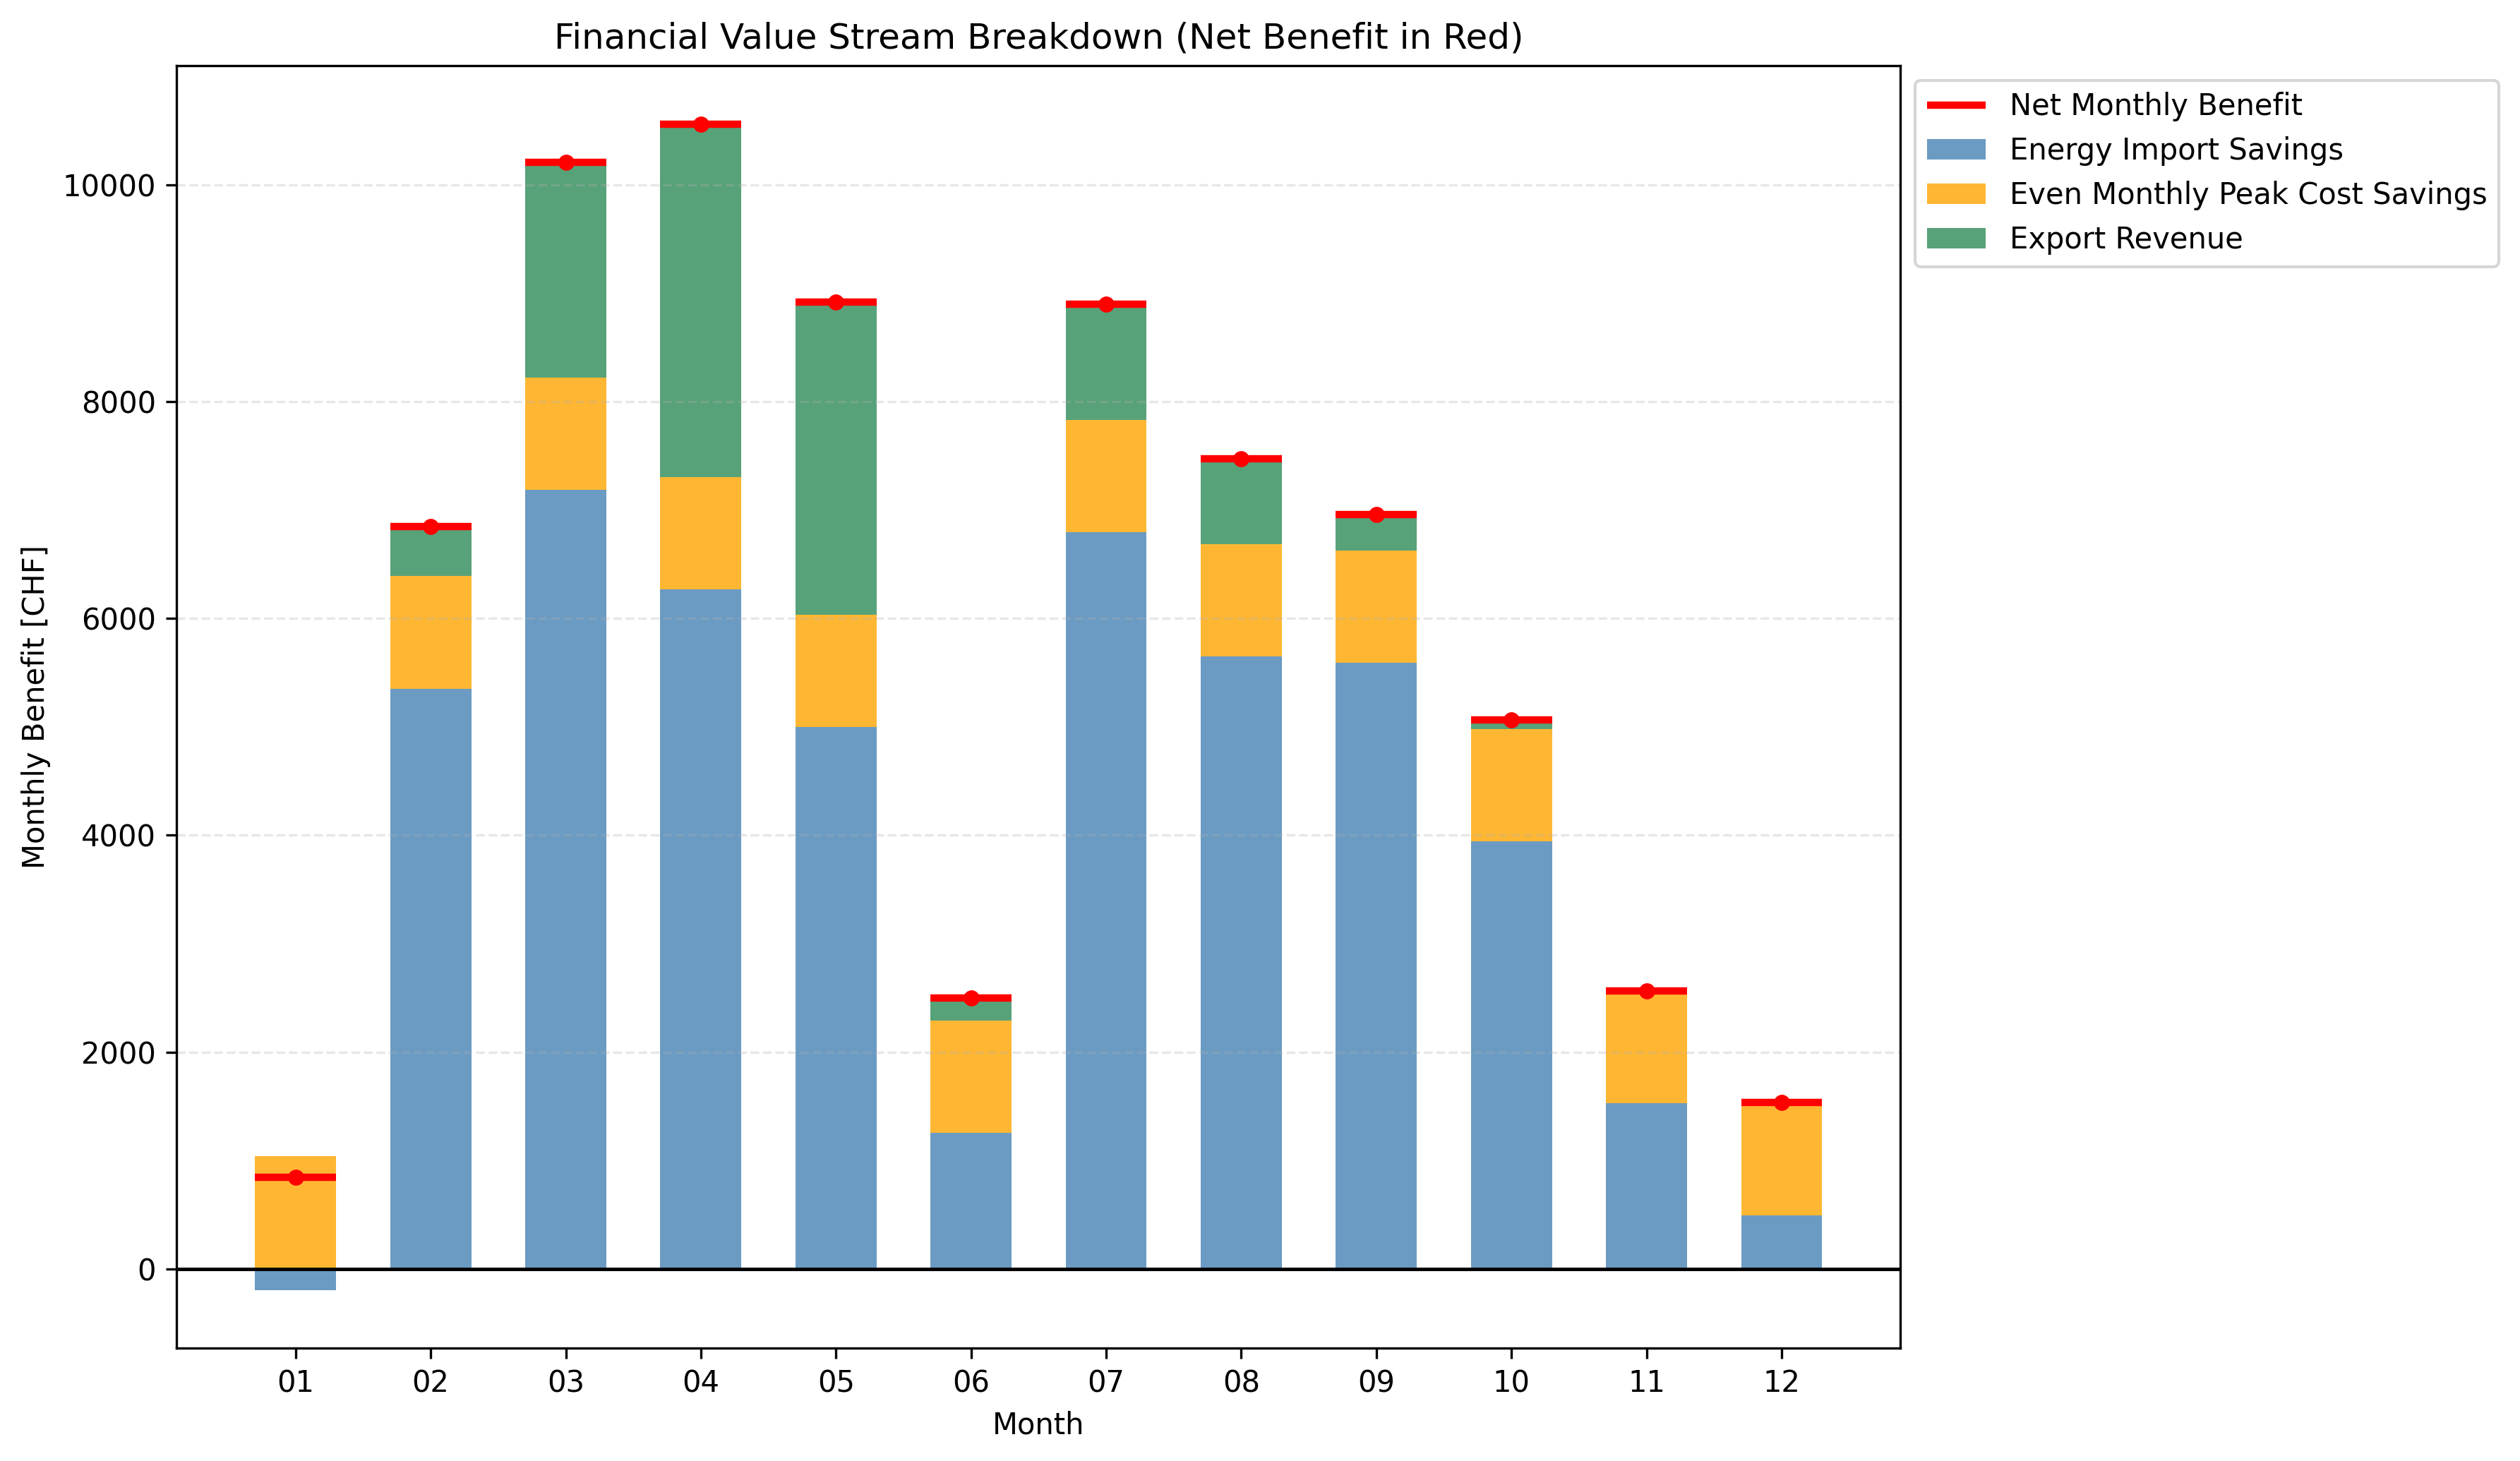

In [83]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# ==============================================================================
# 1. Prepare Data & Ensure Consistent Types
# ==============================================================================
# Convert months to strings like "01", "02", etc., or "2025-01" to guarantee
# clean categorical spacing on the X-axis.
if hasattr(df_monthly["month"].dtype, "str"):
    # If it's a pandas Period or Datetime object
    months_labels = df_monthly["month"].dt.strftime("%m").values
else:
    # If it's a string '2025-01', just grab the month part '01'
    months_labels = df_monthly["month"].str.split("-").str[-1].values

# Convert everything to standard numpy arrays to prevent pandas indexing bugs
energy = df_monthly["energy_import_savings"].to_numpy()
peak = df_monthly["peak_shaving_savings"].to_numpy()
export = df_monthly["monthly_export_revenue"].to_numpy()
net_benefit = energy + peak + export

# Create continuous x positions for reliable plotting/alignment
x_positions = np.arange(len(months_labels))

# ==============================================================================
# 2. Plot Bars (With Masking Fixes)
# ==============================================================================
pos_bottom = np.zeros(len(df_monthly))
neg_bottom = np.zeros(len(df_monthly))

streams = [
    (energy, "steelblue", "Energy Import Savings"),
    (peak, "orange", "Even Monthly Peak Cost Savings"),
    (export, "seagreen", "Export Revenue")
]

for data, color, label in streams:
    pos_mask = data >= 0
    neg_mask = data < 0
    
    # We pass x_positions[mask] instead of months[mask] to guarantee correct alignment
    if np.any(pos_mask):
        ax.bar(x_positions[pos_mask], data[pos_mask], bottom=pos_bottom[pos_mask], 
               color=color, label=label, width=0.6, alpha=0.8)
    if np.any(neg_mask):
        # We don't add a label here to prevent duplicate legend entries natively
        ax.bar(x_positions[neg_mask], data[neg_mask], bottom=neg_bottom[neg_mask], 
               color=color, width=0.6, alpha=0.8)
    
    # Update bottoms
    pos_bottom += np.where(pos_mask, data, 0)
    neg_bottom += np.where(neg_mask, data, 0)

# ==============================================================================
# 3. Plot Net Benefit Line
# ==============================================================================
# Now xmin and xmax line up exactly with our fixed x_positions!
ax.hlines(y=net_benefit, xmin=x_positions - 0.3, xmax=x_positions + 0.3, 
          color="red", linewidth=2.5, label="Net Monthly Benefit", zorder=5)

# Optional: Add small dots to show where the net benefit steps are centered
ax.scatter(x_positions, net_benefit, color="red", s=20, zorder=6)

# ==============================================================================
# 4. Final Formatting & X-Ticks
# ==============================================================================
ax.axhline(0, color="black", linewidth=1.2, zorder=4) # Thick zero line
ax.set_ylabel("Monthly Benefit [CHF]")
ax.set_title("Financial Value Stream Breakdown (Net Benefit in Red)")

# Set the X-ticks explicitly to our clean strings ("01", "02"...)
ax.set_xticks(x_positions)
ax.set_xticklabels(months_labels, rotation=0) # Kept at 0 since "01" is short and clear!
ax.set_xlabel("Month")

# Clean up legend safely
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left", bbox_to_anchor=(1, 1))

ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()

# Save and show
save_path = latest_run / f"Financial_Value_Stream_Breakdown_spot_year_{config.Spot_price_year}.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [84]:
def _plot_weekly_savings(pdf: PdfPages, df_weekly: pd.DataFrame) -> None:
    required = {"week_start", "energy_import_savings", "peak_shaving_savings", "weekly_export_revenue"}
    if not required.issubset(df_weekly.columns) or df_weekly.empty:
        return

    # 1. Setup Figure (Landscape A4)
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    
    # Sort by date for a proper timeline
    df_w = df_weekly.copy()
    df_w["week_start"] = pd.to_datetime(df_w["week_start"])
    df_w = df_w.sort_values("week_start")
    
    # Filter to current year only (to avoid the 2025-01 issue)
    target_year = df_w["week_start"].dt.year.iloc[0]
    df_w = df_w[df_w["week_start"].dt.year == target_year]

    weeks = df_w["week_start"]
    energy = df_w["energy_import_savings"].to_numpy()
    peak = df_w["peak_shaving_savings"].to_numpy()
    export = df_w["weekly_export_revenue"].to_numpy()
    net_benefit = energy + peak + export

    pos_bottom = np.zeros(len(df_w))
    neg_bottom = np.zeros(len(df_w))

    streams = [
        (energy, _BRAND["secondary"], "Energy Import Savings"),
        (peak, _BRAND["accent"], "Peak Shaving Savings"),
        (export, _BRAND["ok"], "Export Revenue")
    ]

    # 2. Plot Stacked Bars
    for data, color, label in streams:
        pos_mask = data >= 0
        neg_mask = data < 0
        
        # We use a narrower width (e.g. 5 days) because the x-axis is datetime based
        width = 5.0 

        if pos_mask.any():
            ax.bar(weeks[pos_mask], data[pos_mask], bottom=pos_bottom[pos_mask], 
                   color=color, label=label, width=width, alpha=0.85)
        if neg_mask.any():
            ax.bar(weeks[neg_mask], data[neg_mask], bottom=neg_bottom[neg_mask], 
                   color=color, width=width, alpha=0.85)
        
        pos_bottom += np.where(pos_mask, data, 0)
        neg_bottom += np.where(neg_mask, data, 0)

    # 3. Plot Net Benefit "Bar-Lines" (Red dashes)
    # Since x-axis is dates, we calculate the xmin/xmax using Timedelta
    half_width = pd.Timedelta(days=2.5)
    ax.hlines(y=net_benefit, xmin=weeks - half_width, xmax=weeks + half_width, 
              color=_BRAND["primary"], linewidth=2.5, label="Net Weekly Benefit", zorder=10)

    # 4. Final Styling
    _style_axes(ax, "Weekly Financial Value Streams", xlabel="Week Start", ylabel="Benefit [CHF/week]")
    ax.axhline(0, color="black", linewidth=1.2, zorder=5)
    
    # Legend management (handle outside)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=True)

    # Better date formatting for 52 bars
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

## Electricity Price Trends by Week

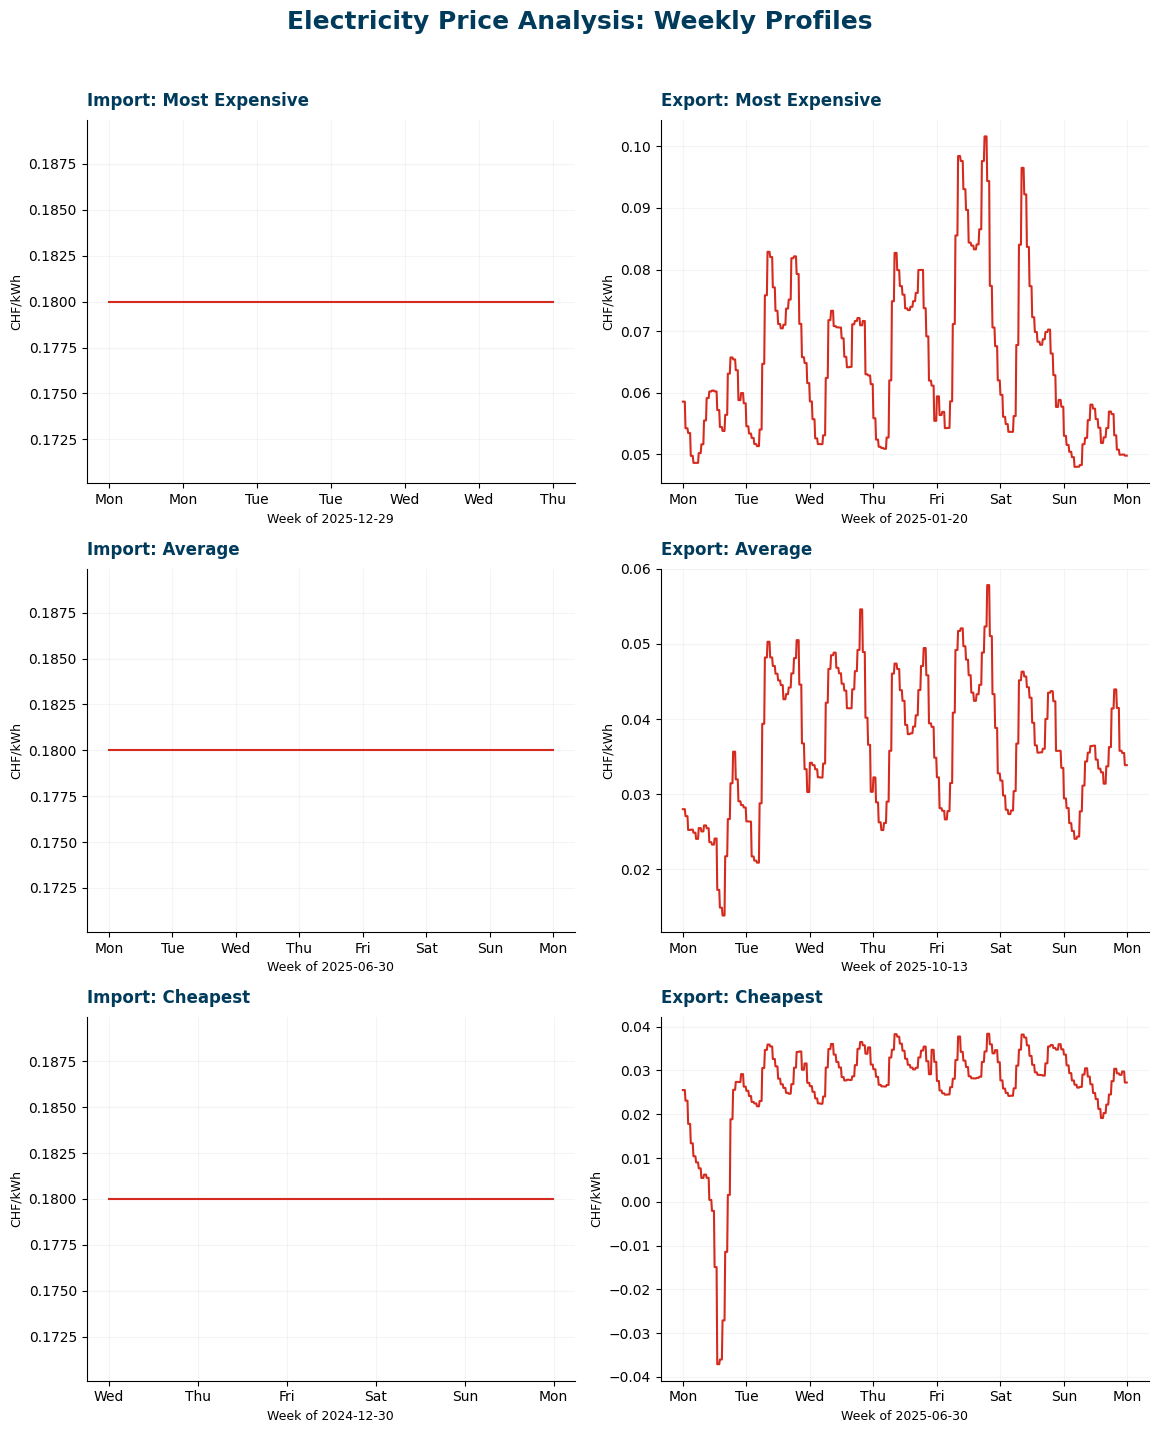

In [85]:
# 1. Branding & Styling Configuration
_BRAND = {
    "primary": "#D52B1E",   # Red
    "secondary": "#003B5C", # Dark Blue
    "grid": "#D6DCE3",
}

def _style_axes(ax, title: str, xlabel: str | None = None, ylabel: str | None = None) -> None:
    ax.set_title(title, loc="left", color=_BRAND["secondary"], pad=10, fontweight="bold")
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3, color=_BRAND["grid"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# 2. Data Preparation & Validation
display(Markdown("## Electricity Price Trends by Week"))

required = {"timestamp", "import_price_with_grid", "export_price"}
if not required.issubset(df.columns):
    display(Markdown("_Required price columns are missing from the dataframe._"))
else:
    # Ensure proper datetime format
    ts = df[["timestamp", "import_price_with_grid", "export_price"]].copy()
    ts["timestamp"] = pd.to_datetime(ts["timestamp"], errors="coerce")
    ts = ts.dropna(subset=["timestamp"]).sort_values("timestamp")
    
    # Calculate weekly metrics to find interesting weeks
    ts["week_start"] = ts["timestamp"].dt.to_period("W").apply(lambda p: p.start_time)
    weekly_avg = ts.groupby("week_start").agg(
        avg_import=("import_price_with_grid", "mean"),
        avg_export=("export_price", "mean")
    ).dropna()

    if weekly_avg.empty:
        display(Markdown("_No valid weekly data found._"))
    else:
        # Helper to pick the 3 representative weeks (Max, Median, Min)
        def get_sample_weeks(series):
            sorted_w = series.sort_values().index.tolist()
            if len(sorted_w) < 3: return sorted_w * 3
            return [sorted_w[-1], sorted_w[len(sorted_w)//2], sorted_w[0]]

        import_weeks = get_sample_weeks(weekly_avg["avg_import"])
        export_weeks = get_sample_weeks(weekly_avg["avg_export"])

        # 3. Plotting Execution (A3 Portrait Size)
        fig, axes = plt.subplots(3, 2, figsize=(11.69, 14), sharex=False)
        fig.suptitle("Electricity Price Analysis: Weekly Profiles", 
                     fontsize=18, fontweight="bold", color=_BRAND["secondary"], y=1.02)

        # Config mapping for the 6 subplots
        plot_map = [
            (import_weeks[0], "Import: Most Expensive", "import_price_with_grid", axes[0, 0]),
            (import_weeks[1], "Import: Average", "import_price_with_grid", axes[1, 0]),
            (import_weeks[2], "Import: Cheapest", "import_price_with_grid", axes[2, 0]),
            (export_weeks[0], "Export: Most Expensive", "export_price", axes[0, 1]),
            (export_weeks[1], "Export: Average", "export_price", axes[1, 1]),
            (export_weeks[2], "Export: Cheapest", "export_price", axes[2, 1]),
        ]

        for week_start, title, col, ax in plot_map:
            week_end = week_start + pd.Timedelta(days=7)
            mask = (ts["timestamp"] >= week_start) & (ts["timestamp"] < week_end)
            week_df = ts[mask]
            
            if not week_df.empty:
                ax.plot(week_df["timestamp"], week_df[col], color=_BRAND["primary"], lw=1.5)
                _style_axes(ax, title, 
                           xlabel=f"Week of {week_start.strftime('%Y-%m-%d')}", 
                           ylabel="CHF/kWh")
                
                # Format X-axis for days of the week
                ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%a'))
                
        plt.tight_layout()
        save_path = latest_run / f"Weekly_Electricity_Price_Curve_spot_year_{config.Spot_price_year}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

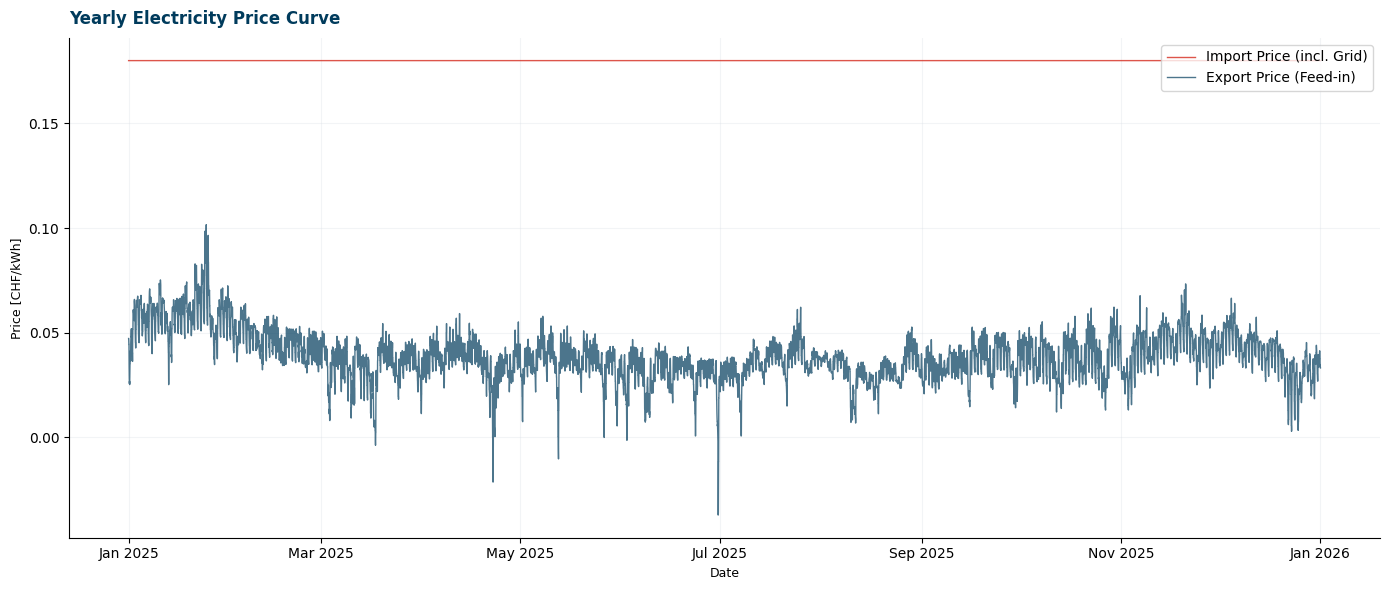

In [86]:
# Create a large single plot for the full year
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Import Price
line1, = ax1.plot(df["timestamp"], df["import_price_with_grid"], 
                 color=_BRAND["primary"], label="Import Price (incl. Grid)", alpha=0.8, lw=1)

# Plot Export Price
line2, = ax1.plot(df["timestamp"], df["export_price"], 
                 color=_BRAND["secondary"], label="Export Price (Feed-in)", alpha=0.7, lw=1)

# Styling
_style_axes(ax1, "Yearly Electricity Price Curve", xlabel="Date", ylabel="Price [CHF/kWh]")
ax1.legend(handles=[line1, line2], loc="upper right")

# Better date formatting for a full year
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

plt.tight_layout()
save_path = latest_run / f"Yearly_Electricity_Price_Curve_spot_year_{config.Spot_price_year}.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [87]:
display(Markdown("## Battery Utilization Metrics"))
display(df_battery_util.style.format({"Value": format_value}))

## Battery Utilization Metrics

,Metric,Value,Unit
0,Charged energy,"394,331.93",kWh/year
1,Discharged energy,"337,326.52",kWh/year
2,Equivalent full cycles,195.83,cycles/year
3,Average state of charge,670.50,kWh
4,Minimum state of charge,344.51,kWh
5,Maximum state of charge,"1,722.53",kWh
6,Hours near empty (<=10%),0.00,hours
7,Hours near full (>=90%),639.75,hours
8,Maximum charge power used,690.89,kW
9,Maximum discharge power used,690.89,kW


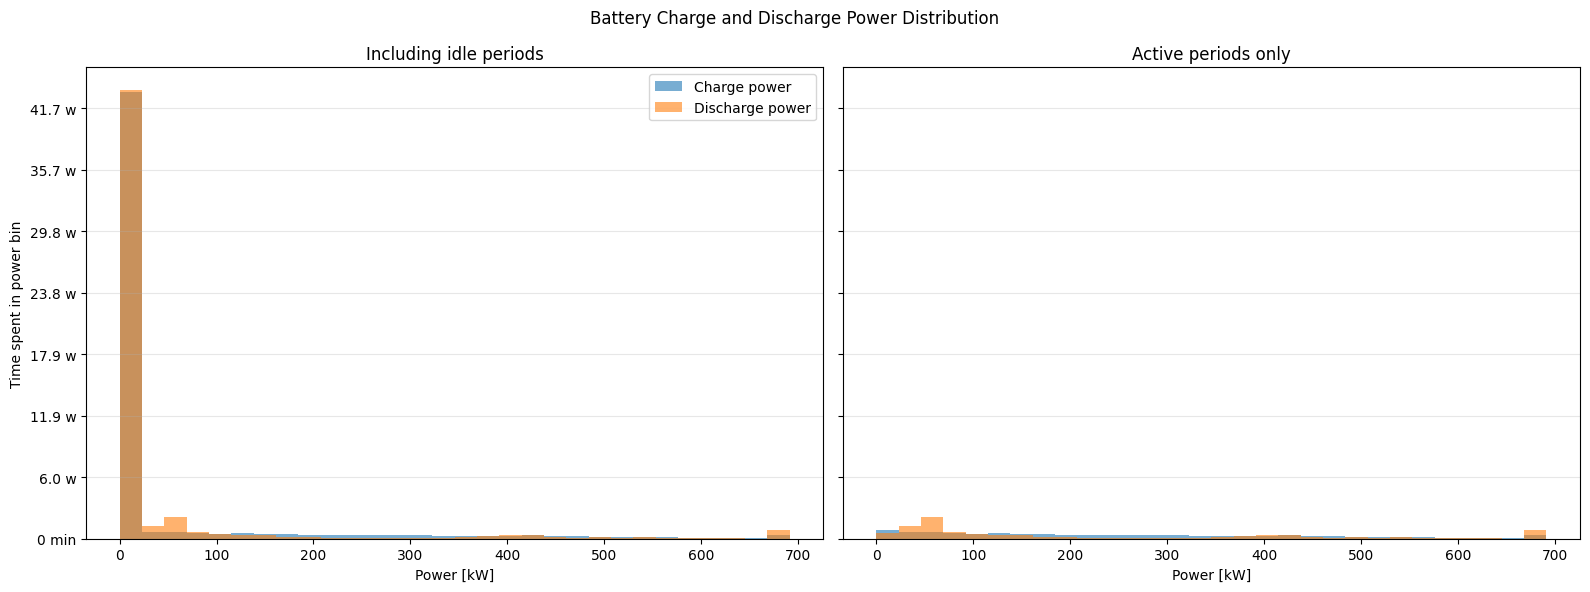

In [88]:
if {"battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    charge_power_all = df["battery_charge_power"]
    discharge_power_all = df["battery_discharge_power"]
    charge_power_active = df.loc[df["battery_charge_power"] > 1e-9, "battery_charge_power"]
    discharge_power_active = df.loc[df["battery_discharge_power"] > 1e-9, "battery_discharge_power"]

    combined_power = pd.concat([charge_power_all, discharge_power_all], ignore_index=True)
    if combined_power.empty:
        common_bins = 30
    else:
        power_min = float(combined_power.min())
        power_max = float(combined_power.max())
        if np.isclose(power_min, power_max):
            power_max = power_min + 1.0
        common_bins = np.linspace(power_min, power_max, 31)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
    plot_configs = [
        (axes[0], charge_power_all, discharge_power_all, "Including idle periods"),
        (axes[1], charge_power_active, discharge_power_active, "Active periods only"),
    ]

    for ax, charge_series, discharge_series, subtitle in plot_configs:
        if not charge_series.empty:
            ax.hist(
                charge_series,
                bins=common_bins,
                weights=np.full(len(charge_series), timestep_hours),
                alpha=0.6,
                label="Charge power",
                color="tab:blue",
            )
        if not discharge_series.empty:
            ax.hist(
                discharge_series,
                bins=common_bins,
                weights=np.full(len(discharge_series), timestep_hours),
                alpha=0.6,
                label="Discharge power",
                color="tab:orange",
            )
        ax.set_xlabel("Power [kW]")
        ax.set_title(subtitle)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(duration_tick_formatter))
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Time spent in power bin")
    axes[0].legend()
    fig.suptitle("Battery Charge and Discharge Power Distribution")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Run the model again to generate charge/discharge power distributions for this section._"))

In [89]:
display(Markdown("## Battery Size Sensitivity"))
if df_battery_sensitivity.empty:
    display(Markdown("_No sensitivity file found for this run. Set `run_battery_size_sensitivity=True` in `config.py`, then run the model again. If `battery_sensitivity_sizes_kwh` is empty, default sizes around the optimized battery are generated automatically._"))
else:
    sensitivity_formatters = {
        "battery_size_kwh": format_value,
        "optimized_battery_capacity_kwh": format_value,
        "optimized_battery_power_capacity_kw": format_value,
        "objective_total_cost": format_value,
        "import_cost": format_value,
        "peak_demand_cost": format_value,
        "annualized_battery_cost": format_value,
        "annual_savings": format_value,
        "npv": format_value,
        "irr": format_value,
        "payback_years": format_value,
        "discounted_payback_years": format_value,
    }
    sensitivity_formatters = {key: value for key, value in sensitivity_formatters.items() if key in df_battery_sensitivity.columns}
    display(df_battery_sensitivity.style.format(sensitivity_formatters))

## Battery Size Sensitivity

,battery_size_kwh,optimized_battery_capacity_kwh,optimized_battery_power_capacity_kw,objective_total_cost,import_cost,peak_demand_cost,annualized_battery_cost,annual_savings,npv,irr,payback_years,discounted_payback_years,status
0,0.00,0.00,0.00,"583,860.87","548,041.23","35,819.64",0.00,0.00,0.00,-,-,-,baseline
1,430.63,430.63,-,-,-,-,-,-,-,-,-,-,infeasible
2,861.26,861.26,-,-,-,-,-,-,-,-,-,-,infeasible
3,"1,291.89","1,291.89",645.95,"557,347.22","507,909.27","24,192.59","28,156.42","54,670.08","235,581.05",0.12,8.00,10.00,optimal
4,"1,722.53","1,722.53",690.89,"556,553.07","499,169.47","23,383.56","35,066.46","62,374.26","214,761.66",0.10,8.00,11.00,optimal
5,"2,153.16","2,153.16",711.85,"557,189.02","492,164.80","23,006.29","41,627.98","68,299.83","175,858.52",0.09,9.00,13.00,optimal
6,"2,583.79","2,583.79",723.47,"558,885.07","486,427.90","22,797.19","48,053.75","73,029.55","122,987.15",0.08,10.00,14.00,optimal
7,"3,445.05","3,445.05",798.40,"564,277.04","477,620.97","21,448.44","61,656.44","81,240.27","-13,734.95",0.06,11.00,-,optimal


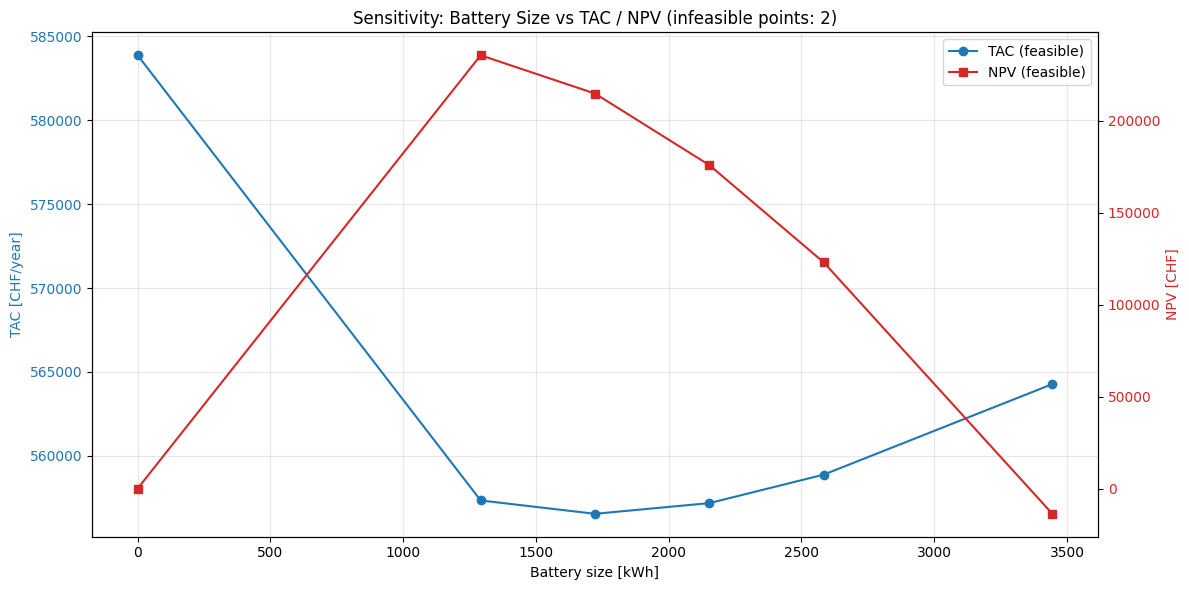

In [90]:
plot_df = df_battery_sensitivity.copy()
required_x = "battery_size_kwh"
required_any_y = ["objective_total_cost", "npv"]

if plot_df.empty:
    display(Markdown("_No sensitivity results available yet for this run._"))
elif required_x not in plot_df.columns:
    display(Markdown("_Sensitivity results found, but `battery_size_kwh` is missing. Please regenerate `battery_size_sensitivity.csv`._"))
else:
    available_y = [col for col in required_any_y if col in plot_df.columns]
    if not available_y:
        display(Markdown("_Sensitivity results found, but required KPI columns (`objective_total_cost` / `npv`) are missing. Please regenerate `battery_size_sensitivity.csv`._"))
    else:
        if "status" in plot_df.columns:
            feasible_df = plot_df[plot_df["status"].isin(["baseline", "optimal"])].copy()
            infeasible_df = plot_df[plot_df["status"] == "infeasible"].copy()
        else:
            feasible_df = plot_df.copy()
            infeasible_df = pd.DataFrame(columns=plot_df.columns)

        if feasible_df.empty and infeasible_df.empty:
            display(Markdown("_No sensitivity points available to plot._"))
        else:
            fig, ax1 = plt.subplots(figsize=(12, 6))
            ax1.set_xlabel("Battery size [kWh]")
            ax1.grid(True, alpha=0.3)

            # Feasible TAC curve
            if "objective_total_cost" in feasible_df.columns and not feasible_df.empty:
                feasible_df_sorted = feasible_df.sort_values(required_x)
                ax1.plot(
                    feasible_df_sorted[required_x],
                    feasible_df_sorted["objective_total_cost"],
                    marker="o",
                    color="tab:blue",
                    label="TAC (feasible)",
                )
                ax1.set_ylabel("TAC [CHF/year]", color="tab:blue")
                ax1.tick_params(axis="y", labelcolor="tab:blue")
            else:
                ax1.set_ylabel("TAC [CHF/year]")

            # Infeasible points (projected onto left axis if KPI available)
            if not infeasible_df.empty and "objective_total_cost" in infeasible_df.columns:
                infeasible_plot = infeasible_df.dropna(subset=["objective_total_cost"])
                if not infeasible_plot.empty:
                    ax1.scatter(
                        infeasible_plot[required_x],
                        infeasible_plot["objective_total_cost"],
                        color="crimson",
                        marker="x",
                        s=70,
                        label="Infeasible points",
                    )

            ax2 = None
            if "npv" in plot_df.columns:
                ax2 = ax1.twinx()
                if not feasible_df.empty:
                    feasible_df_sorted = feasible_df.sort_values(required_x)
                    ax2.plot(
                        feasible_df_sorted[required_x],
                        feasible_df_sorted["npv"],
                        marker="s",
                        color="tab:red",
                        label="NPV (feasible)",
                    )
                if not infeasible_df.empty:
                    infeasible_npv = infeasible_df.dropna(subset=["npv"])
                    if not infeasible_npv.empty:
                        ax2.scatter(
                            infeasible_npv[required_x],
                            infeasible_npv["npv"],
                            color="crimson",
                            marker="x",
                            s=70,
                            label="NPV infeasible points",
                        )
                ax2.set_ylabel("NPV [CHF]", color="tab:red")
                ax2.tick_params(axis="y", labelcolor="tab:red")

            # Consolidated legend
            handles, labels = ax1.get_legend_handles_labels()
            if ax2 is not None:
                h2, l2 = ax2.get_legend_handles_labels()
                handles += h2
                labels += l2
            if handles:
                ax1.legend(handles, labels, loc="best")

            infeasible_count = len(infeasible_df) if not infeasible_df.empty else 0
            plt.title(f"Sensitivity: Battery Size vs TAC / NPV (infeasible points: {infeasible_count})")
            plt.tight_layout()
            plt.show()

## Representative Dispatch Weeks

**Load definitions used in this section**  
Optimization balance per timestep:  
$grid\_flow_t + pv\_flow_t + battery\_discharge_t - battery\_charge_t = total\_demand_t$  

Derived reporting metric (actual load including battery charging):  
$actual\_load_t = grid\_flow_t + pv\_flow_t + battery\_discharge_t = total\_demand_t + battery\_charge_t$

,label,week_start
0,Winter Week,2025-12-01
1,Summer Week,2025-07-07
2,Highest-Load Week,2025-11-24


Each representative week is split into three panels: (1) site net load and supply sources, (2) battery charging and discharging around a zero line, and (3) battery state of charge with the electricity price as dashed reference.

### Winter Week | Week of 2025-12-01  Peak net load: **1,745 kW**, peak actual load: **1,745 kW**, total net load: **81,484 kWh**, total actual load: **85,086 kWh**, PV used: **5,490 kWh**, grid import: **76,870 kWh**, grid export: **0 kWh**, battery charge/discharge: **3,602 / 2,726 kWh**, average price: **0.000 CHF/kWh**

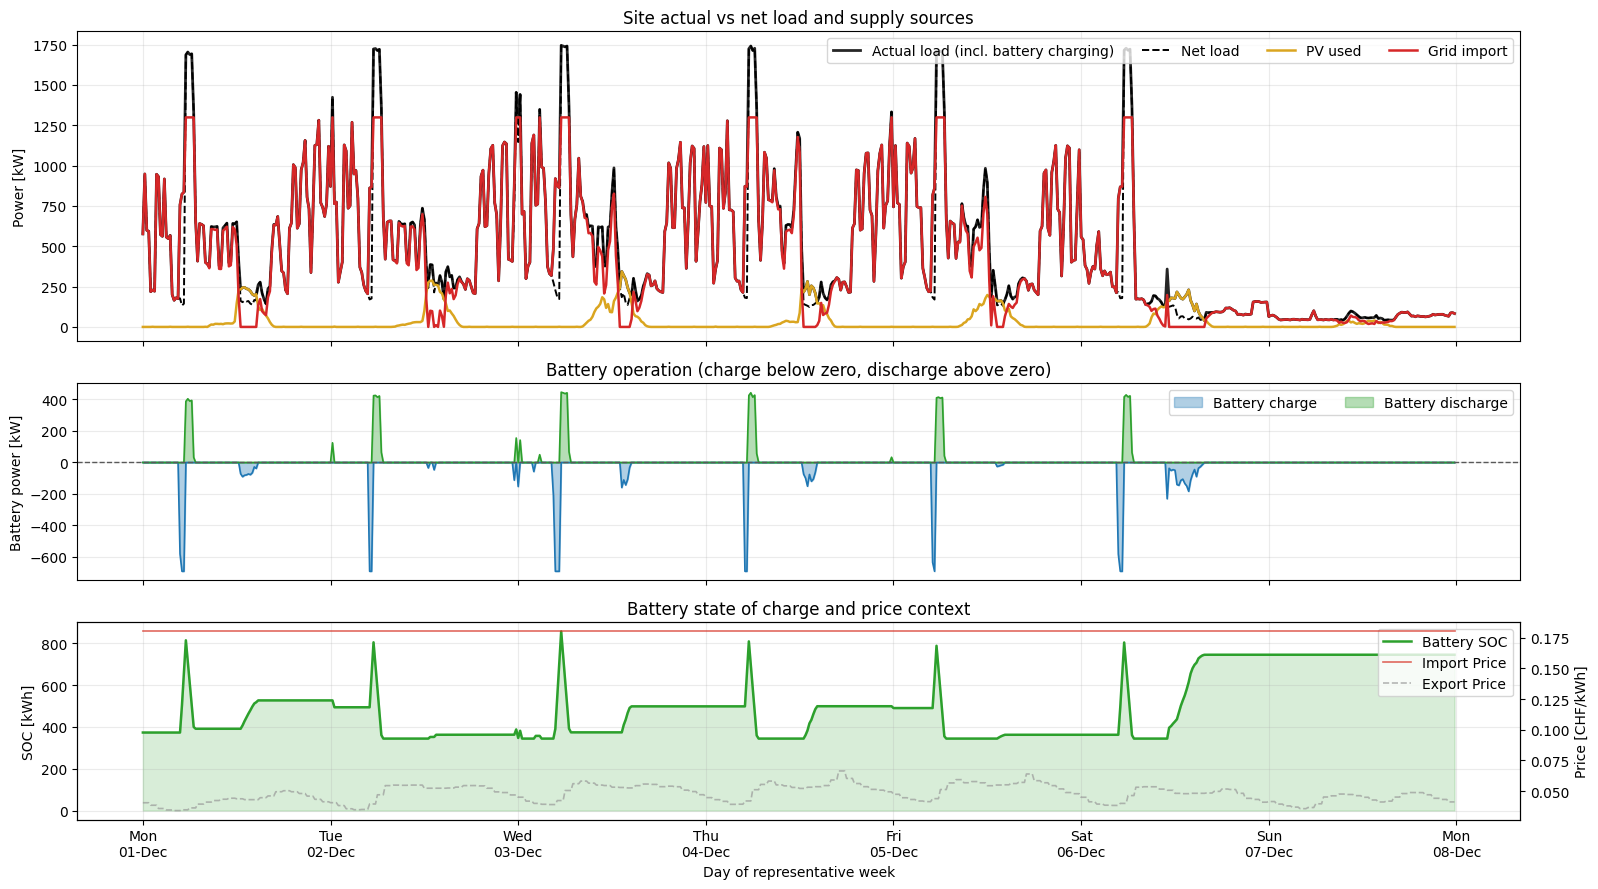

### Summer Week | Week of 2025-07-07  Peak net load: **1,084 kW**, peak actual load: **1,084 kW**, total net load: **61,009 kWh**, total actual load: **82,102 kWh**, PV used: **36,791 kWh**, grid import: **36,654 kWh**, grid export: **10,910 kWh**, battery charge/discharge: **10,183 / 8,656 kWh**, average price: **0.000 CHF/kWh**

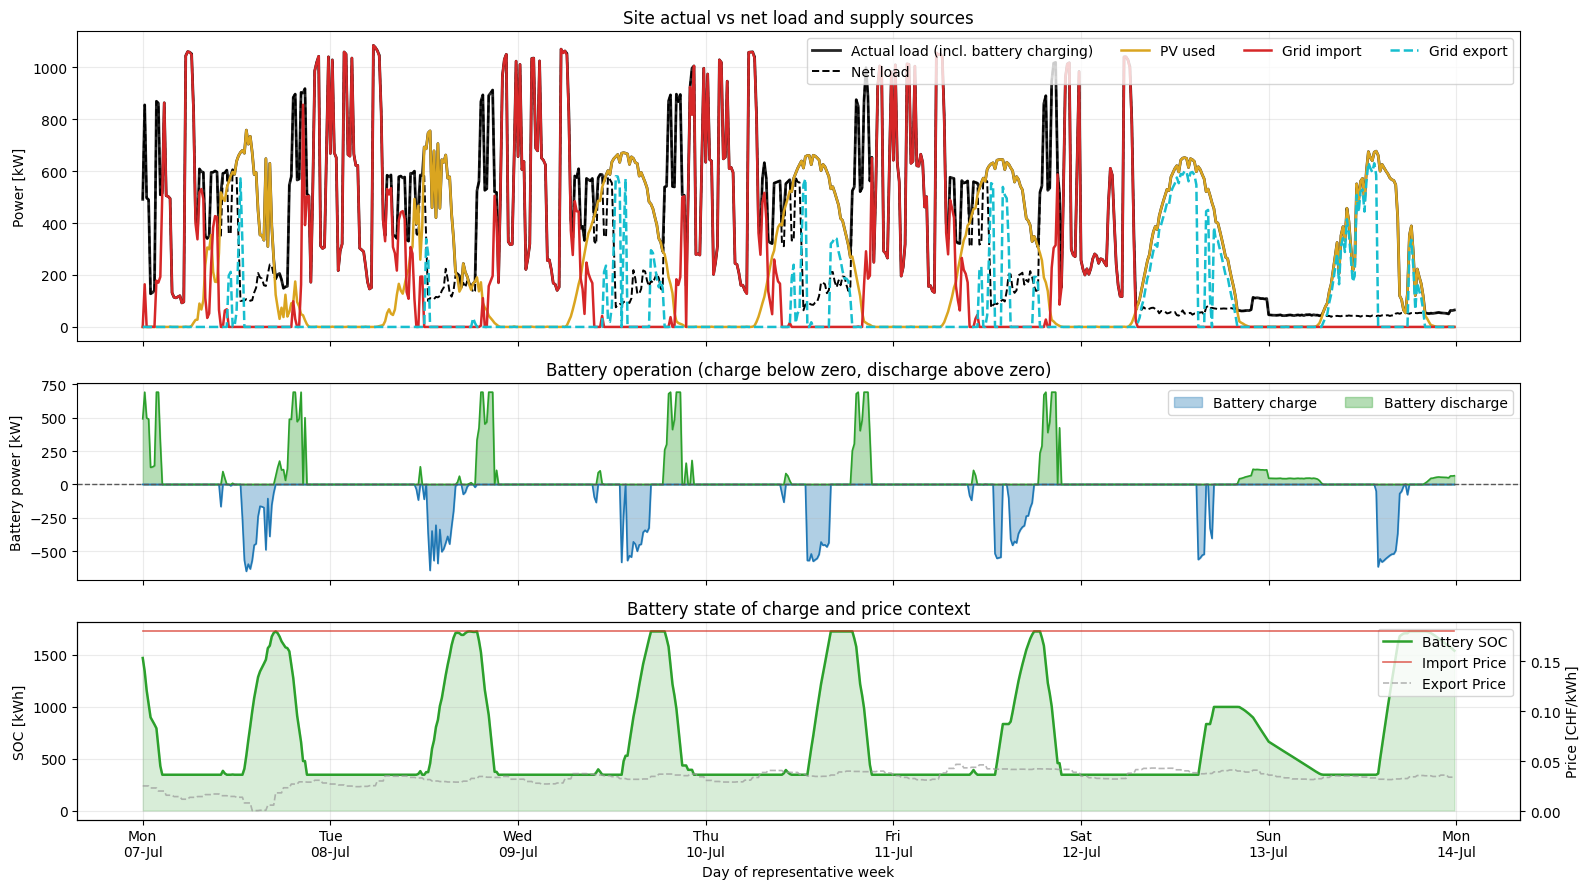

### Highest-Load Week | Week of 2025-11-24  Peak net load: **1,756 kW**, peak actual load: **1,756 kW**, total net load: **83,462 kWh**, total actual load: **85,442 kWh**, PV used: **875 kWh**, grid import: **81,876 kWh**, grid export: **0 kWh**, battery charge/discharge: **1,980 / 2,691 kWh**, average price: **0.000 CHF/kWh**

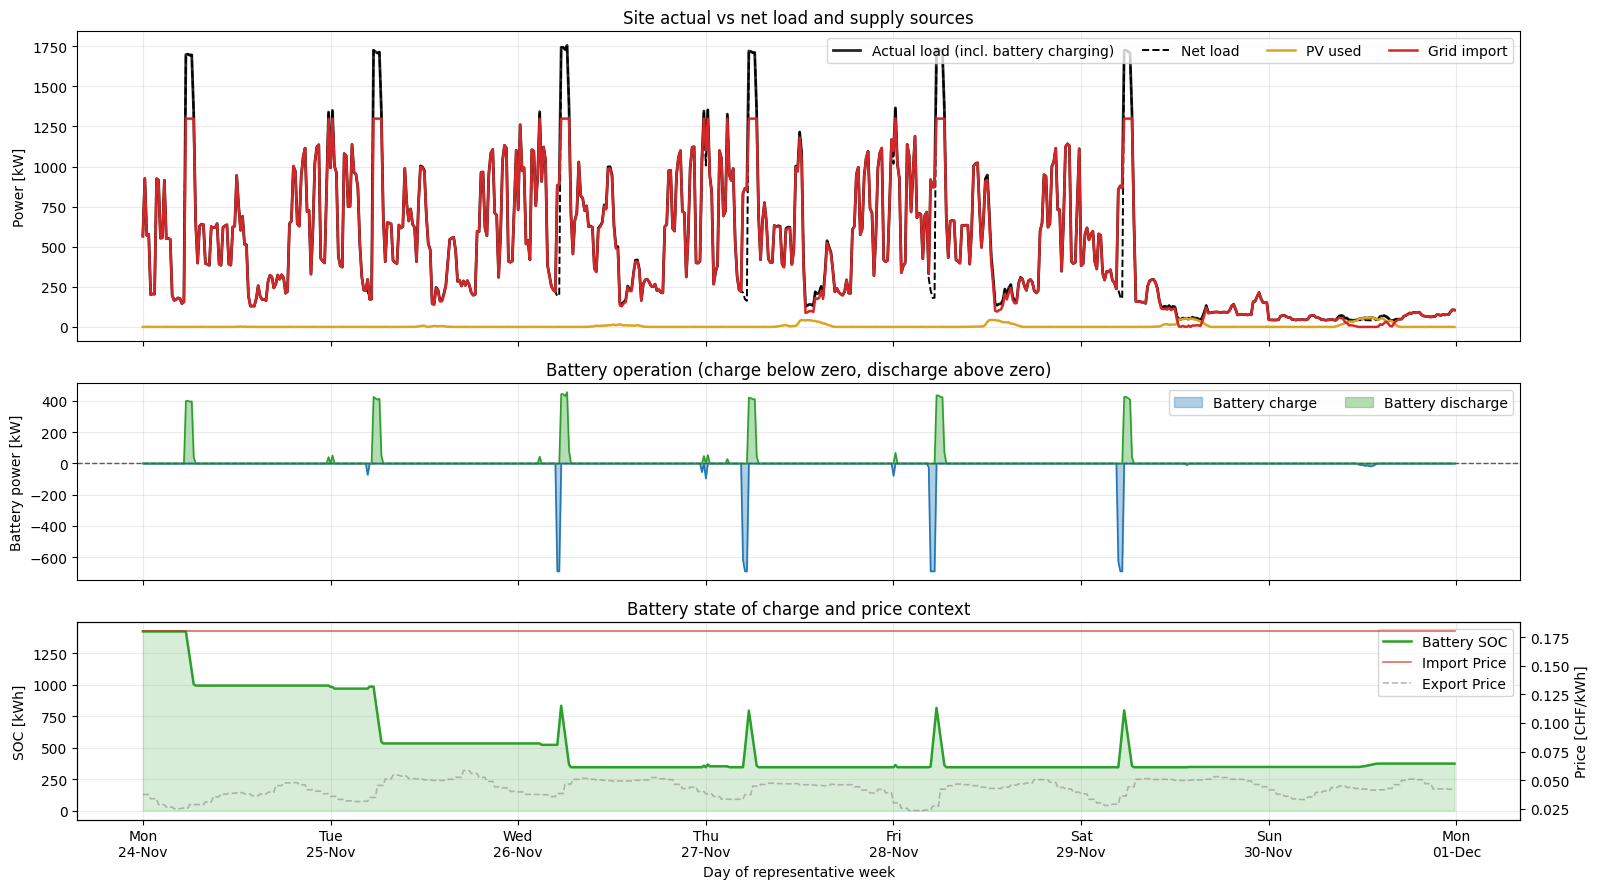

In [91]:
display(Markdown("## Representative Dispatch Weeks"))
display(Markdown(
    "**Load definitions used in this section**  \n"
    "Optimization balance per timestep:  \n"
    "$grid\\_flow_t + pv\\_flow_t + battery\\_discharge_t - battery\\_charge_t = total\\_demand_t$  \n\n"
    "Derived reporting metric (actual load including battery charging):  \n"
    "$actual\\_load_t = grid\\_flow_t + pv\\_flow_t + battery\\_discharge_t = total\\_demand_t + battery\\_charge_t$"
))
if dispatch_week_table.empty:
    display(Markdown("_No representative dispatch weeks could be identified for this run._"))
else:
    display(dispatch_week_table.style.format({"week_start": lambda v: pd.to_datetime(v).strftime('%Y-%m-%d')}))
    display(Markdown(
        "Each representative week is split into three panels: "
        "(1) site net load and supply sources, "
        "(2) battery charging and discharging around a zero line, and "
        "(3) battery state of charge with the electricity price as dashed reference."
    ))

    for week_info in selected_dispatch_weeks:
        start = pd.to_datetime(week_info["week_start"])
        end = start + pd.Timedelta(days=7)
        week_df = dispatch_df[(dispatch_df["timestamp"] >= start) & (dispatch_df["timestamp"] < end)].copy()

        if week_df.empty:
            display(Markdown(f"### {week_info['label']}"))
            display(Markdown("_No data available for this representative week._"))
            continue

        week_df["actual_load"] = (
            week_df["grid_flow"]
            + week_df["pv_flow"]
            + week_df["battery_discharge_power"]
        )

        total_net_load = week_df["total_load"].sum() * timestep_hours
        total_actual_load = week_df["actual_load"].sum() * timestep_hours
        avg_price = week_df["electricity_price"].mean()
        peak_net_load = week_df["total_load"].max()
        peak_actual_load = week_df["actual_load"].max()
        total_grid_import = week_df["grid_flow"].sum() * timestep_hours
        total_grid_export = week_df["grid_export"].sum() * timestep_hours
        total_pv_used = week_df["pv_flow"].sum() * timestep_hours
        total_charge = week_df["battery_charge_power"].sum() * timestep_hours
        total_discharge = week_df["battery_discharge_power"].sum() * timestep_hours

        display(Markdown(
            f"### {week_info['label']} | Week of {start.strftime('%Y-%m-%d')}  "
            f"Peak net load: **{peak_net_load:,.0f} kW**, peak actual load: **{peak_actual_load:,.0f} kW**, "
            f"total net load: **{total_net_load:,.0f} kWh**, total actual load: **{total_actual_load:,.0f} kWh**, "
            f"PV used: **{total_pv_used:,.0f} kWh**, grid import: **{total_grid_import:,.0f} kWh**, "
            f"grid export: **{total_grid_export:,.0f} kWh**, "
            f"battery charge/discharge: **{total_charge:,.0f} / {total_discharge:,.0f} kWh**, "
            f"average price: **{avg_price:,.3f} CHF/kWh**"
        ))

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(16, 9),
            sharex=True,
            gridspec_kw={"height_ratios": [2.2, 1.4, 1.4]},
        )
        ax_supply, ax_battery, ax_soc = axes

        ax_supply.plot(week_df["timestamp"], week_df["actual_load"], label="Actual load (incl. battery charging)", color="0.15", linewidth=2.0)
        ax_supply.plot(week_df["timestamp"], week_df["total_load"], label="Net load", color="black", linewidth=1.4, linestyle="--")
        ax_supply.plot(week_df["timestamp"], week_df["pv_flow"], label="PV used", color="goldenrod", linewidth=1.8)
        ax_supply.plot(week_df["timestamp"], week_df["grid_flow"], label="Grid import", color="tab:red", linewidth=1.8)
        if (week_df["grid_export"] > 1e-9).any():
            ax_supply.plot(
                week_df["timestamp"],
                week_df["grid_export"],
                label="Grid export",
                color="tab:cyan",
                linewidth=1.8,
                linestyle="--",
            )
        if (week_df["spill_flow"] > 1e-9).any():
            ax_supply.plot(
                week_df["timestamp"],
                week_df["spill_flow"],
                label="Curtailment",
                color="tab:purple",
                linewidth=1.5,
                linestyle="--",
            )
        ax_supply.set_ylabel("Power [kW]")
        ax_supply.set_title("Site actual vs net load and supply sources")
        ax_supply.grid(True, alpha=0.25)
        ax_supply.legend(loc="upper right", ncol=4)

        charge_series = -week_df["battery_charge_power"].to_numpy(dtype=float)
        discharge_series = week_df["battery_discharge_power"].to_numpy(dtype=float)
        ax_battery.fill_between(week_df["timestamp"], 0, charge_series, color="tab:blue", alpha=0.35, label="Battery charge")
        ax_battery.fill_between(week_df["timestamp"], 0, discharge_series, color="tab:green", alpha=0.35, label="Battery discharge")
        ax_battery.plot(week_df["timestamp"], charge_series, color="tab:blue", linewidth=1.2)
        ax_battery.plot(week_df["timestamp"], discharge_series, color="tab:green", linewidth=1.2)
        ax_battery.axhline(0, color="0.35", linewidth=1.0, linestyle="--")
        ax_battery.set_ylabel("Battery power [kW]")
        ax_battery.set_title("Battery operation (charge below zero, discharge above zero)")
        ax_battery.grid(True, alpha=0.25)
        ax_battery.legend(loc="upper right", ncol=2)

        ax_soc.plot(week_df["timestamp"], week_df["battery_soc"], color="#2ca02c", lw=1.8, label="Battery SOC")
        ax_soc.fill_between(week_df["timestamp"], week_df["battery_soc"], alpha=0.18, color="#2ca02c")
        ax_soc.set_ylabel("SOC [kWh]")
        ax_soc.set_title("Battery state of charge and price context")
        ax_soc.grid(True, alpha=0.25)

        # Create the secondary axis for prices
        ax_price = ax_soc.twinx()
        
        # 1. Plot Import Price (Solid or thicker line)
        ax_price.plot(
            week_df["timestamp"],
            week_df["import_price_with_grid"],
            color=_BRAND["primary"],
            linewidth=1.2,
            linestyle="-",
            label="Import Price",
            alpha=0.7
        )
        
        # 2. Plot Export Price (Dashed line)
        ax_price.plot(
            week_df["timestamp"],
            week_df["export_price"],
            color="0.6",
            linewidth=1.2,
            linestyle="--",
            label="Export Price",
            alpha=0.7
        )

        ax_price.set_ylabel("Price [CHF/kWh]")

        soc_handles, soc_labels = ax_soc.get_legend_handles_labels()
        price_handles, price_labels = ax_price.get_legend_handles_labels()
        ax_soc.legend(soc_handles + price_handles, soc_labels + price_labels, loc="upper right")

        ax_soc.xaxis.set_major_locator(mdates.DayLocator())
        ax_soc.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d-%b"))
        ax_soc.set_xlabel("Day of representative week")

        plt.tight_layout()
        save_path = latest_run / f"Representative_week_{week_info['label']}_spot_year_{config.Spot_price_year}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()


In [92]:
# Weekly energy use by charging vs exporting
weekly_charge_export = dispatch_df.groupby("week_start", as_index=False).agg(
    battery_charge_energy_kwh=("battery_charge_power", "sum"),
    grid_export_energy_kwh=("grid_export", "sum"),
    battery_discharge_energy_kwh=("battery_discharge_power", "sum"),
)
weekly_charge_export["battery_charge_energy_kwh"] *= timestep_hours
weekly_charge_export["grid_export_energy_kwh"] *= timestep_hours
weekly_charge_export["battery_discharge_energy_kwh"] *= timestep_hours
weekly_charge_export["dominant_energy_use"] = np.where(
    weekly_charge_export["battery_charge_energy_kwh"] > weekly_charge_export["grid_export_energy_kwh"],
    "Battery charge",
    np.where(
        weekly_charge_export["grid_export_energy_kwh"] > weekly_charge_export["battery_charge_energy_kwh"],
        "Grid export",
        "Tie"
    )
)

weekly_charge_export = weekly_charge_export.sort_values(
    by=["dominant_energy_use", "battery_charge_energy_kwh", "grid_export_energy_kwh"],
    ascending=[True, False, False]
)

display(Markdown("## Weekly Battery Charge vs Export Summary"))
display(Markdown(
    "This table highlights weeks where energy is used primarily to charge the battery or primarily exported to the grid. "
    "Values are total weekly energy quantities in kWh."
))
display(weekly_charge_export.style.format({
    "battery_charge_energy_kwh": format_value,
    "grid_export_energy_kwh": format_value,
    "battery_discharge_energy_kwh": format_value,
}))

## Weekly Battery Charge vs Export Summary

This table highlights weeks where energy is used primarily to charge the battery or primarily exported to the grid. Values are total weekly energy quantities in kWh.

,week_start,battery_charge_energy_kwh,grid_export_energy_kwh,battery_discharge_energy_kwh,dominant_energy_use
9,2025-03-03 00:00:00,"12,165.63","10,934.21","10,309.30",Battery charge
10,2025-03-10 00:00:00,"11,811.01","7,566.25","10,134.89",Battery charge
26,2025-06-30 00:00:00,"10,573.54","5,803.06","9,117.45",Battery charge
7,2025-02-17 00:00:00,"10,557.38","2,884.44","8,950.05",Battery charge
30,2025-07-28 00:00:00,"10,352.42","8,126.56","8,758.14",Battery charge
37,2025-09-15 00:00:00,"10,258.05","1,575.51","8,870.83",Battery charge
29,2025-07-21 00:00:00,"10,246.14","4,128.32","8,780.21",Battery charge
8,2025-02-24 00:00:00,"9,680.82","7,188.42","8,319.16",Battery charge
32,2025-08-11 00:00:00,"9,457.85","4,863.21","8,356.06",Battery charge
31,2025-08-04 00:00:00,"9,436.59","4,958.36","7,872.68",Battery charge


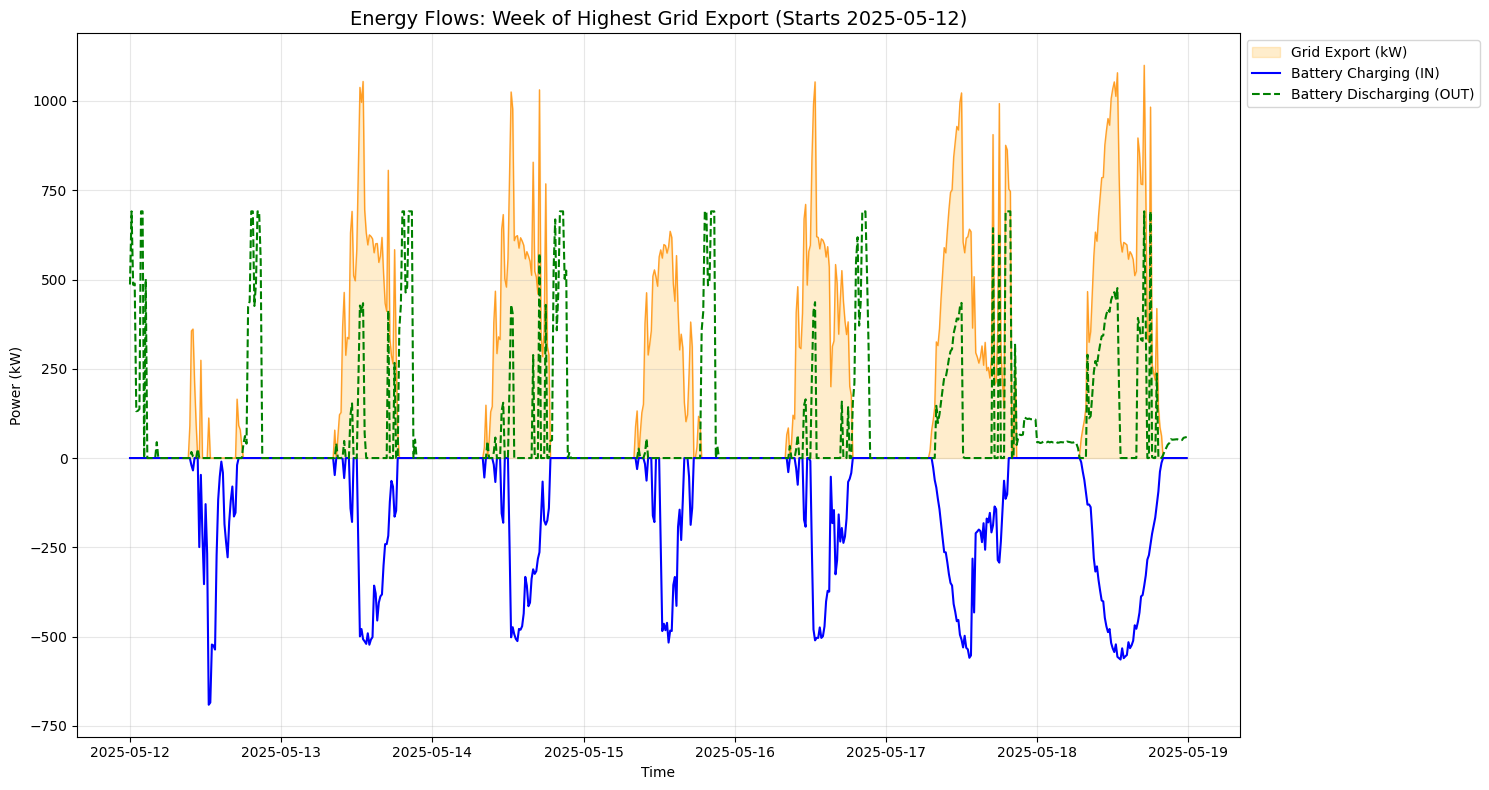

In [93]:
# 1. Find the target week (same as before)
max_export_row = weekly_charge_export.loc[weekly_charge_export['grid_export_energy_kwh'].idxmax()]
target_week = max_export_row['week_start']

# 2. Filter data
week_detail = dispatch_df[
    (dispatch_df['timestamp'] >= target_week) & 
    (dispatch_df['timestamp'] < target_week + pd.Timedelta(days=7))
].copy()

plt.figure(figsize=(15, 8))

# --- GRID EXPORT (The focus) ---
plt.fill_between(week_detail['timestamp'], week_detail['grid_export'], 
                 label='Grid Export (kW)', color='orange', alpha=0.2)
plt.plot(week_detail['timestamp'], week_detail['grid_export'], color='darkorange', linewidth=1, alpha=0.8)

# --- BATTERY CHARGING (Energy going IN) ---
if 'battery_charge_power' in week_detail.columns:
    plt.plot(week_detail['timestamp'], - week_detail['battery_charge_power'], 
             label='Battery Charging (IN)', color='blue', linewidth=1.5)

# --- BATTERY DISCHARGING (Energy going OUT) ---
# We plot this as positive for easy comparison, or negative to show flow direction
if 'battery_discharge_power' in week_detail.columns:
    plt.plot(week_detail['timestamp'], week_detail['battery_discharge_power'], 
             label='Battery Discharging (OUT)', color='green', linewidth=1.5, linestyle='--')

# --- SOLAR PRODUCTION (The source) ---
if 'pv_power' in week_detail.columns:
    plt.plot(week_detail['timestamp'], week_detail['pv_power'], 
             label='PV Production', color='gold', alpha=0.4, linewidth=1)

# Formatting
plt.title(f"Energy Flows: Week of Highest Grid Export (Starts {target_week.date()})", fontsize=14)
plt.ylabel("Power (kW)")
plt.xlabel("Time")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside to see data clearly
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = latest_run / f"highest_grid_export_week_{week_info['label']}_spot_year_{config.Spot_price_year}.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

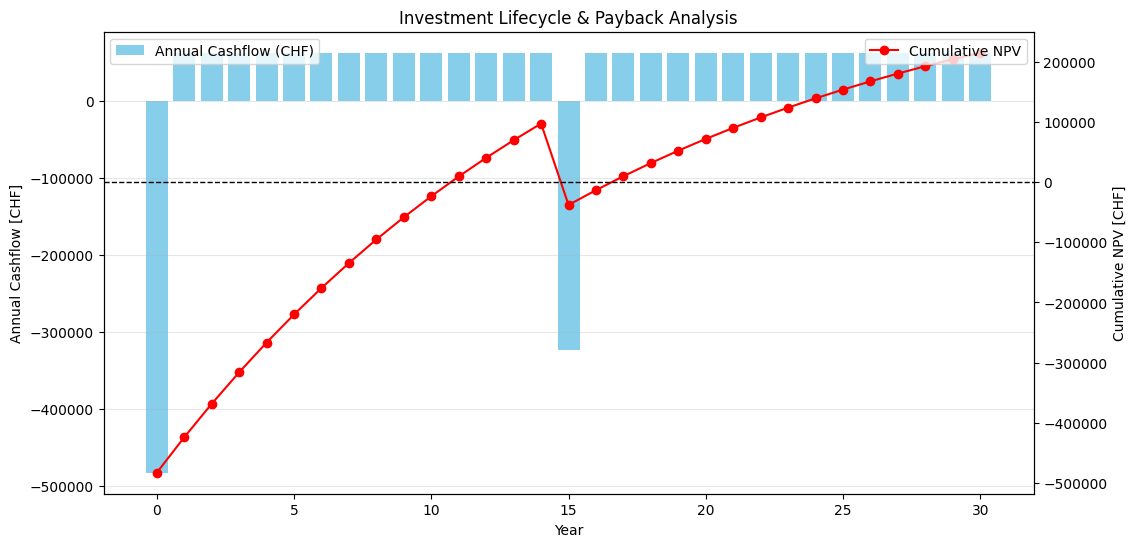

**Battery Energy Size:** 1,722.53 kWh

**Battery Power Rating:** 690.89 kW

**Energy CAPEX:** CHF 344,505.21

**Power CAPEX:** CHF 138,178.64

**Equivalent Full Cycles:** 195.83 cycles/year

...

**Internal Rate of Return (IRR):** 0.1036

**Battery Replacement:** CHF 386,147.08 in year 15

**Curtailed Energy:** 0.00 kWh/year

## Detailed Output Summary

,Metric,Value
0,TAC / Objective Total Cost [CHF/year],"556,553.07"
1,OPEX [CHF/year],"498,103.05"
2,Import Cost [CHF/year],"499,169.47"
3,Peak Demand Cost [CHF/year],"23,383.56"
4,Fixed O&M Cost [CHF/year],"10,000.00"
5,Annualized Battery Cost [CHF/year],"35,066.46"
6,Battery Capacity [kWh],"1,722.53"
7,Battery Power Capacity [kW],690.89
8,Yearly Peak Grid Import [kW],"1,299.09"
9,Sum Monthly Peaks [kW],0.00


In [94]:
## 3. Financial Projection
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_fin['year'], df_fin['cashflow'], color='skyblue', label='Annual Cashflow (CHF)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Cashflow [CHF]')

ax2 = ax1.twinx()
ax2.plot(df_fin['year'], df_fin['discounted_cashflow'].cumsum(), color='red', marker='o', label='Cumulative NPV')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Cumulative NPV [CHF]')

plt.title("Investment Lifecycle & Payback Analysis")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
importlib.reload(config)
save_path = latest_run / f"investment_lifecycle_{config.Spot_price_year}.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

display(Markdown(f"**Battery Energy Size:** {summary.get('battery_capacity_kwh', 0):,.2f} kWh"))
display(Markdown(f"**Battery Power Rating:** {summary.get('battery_power_capacity_kw', 0):,.2f} kW"))
display(Markdown(f"**Energy CAPEX:** CHF {summary.get('energy_investment_cost', 0):,.2f}"))
display(Markdown(f"**Power CAPEX:** CHF {summary.get('power_investment_cost', 0):,.2f}"))
display(Markdown(f"**Equivalent Full Cycles:** {summary.get('equivalent_full_cycles', float('nan')):,.2f} cycles/year"))
display(Markdown(f"**Replacement Basis:** {summary.get('replacement_basis', 'N/A')}"))
display(Markdown(f"**Payback Period:** {summary.get('payback_years', 'N/A')} years"))
display(Markdown(f"**Discounted Payback Period:** {summary.get('discounted_payback_years', 'N/A')} years"))
display(Markdown(f"**Net Present Value (NPV):** CHF {summary.get('npv', 0):,.2f}"))
display(Markdown(f"**Internal Rate of Return (IRR):** {summary.get('irr', float('nan')):,.4f}"))
display(Markdown(f"**Battery Replacement:** CHF {summary.get('replacement_cost', 0):,.2f} in year {summary.get('replacement_year', 'N/A')}"))
display(Markdown(f"**Curtailed Energy:** {summary.get('curtailed_energy_kwh', 0):,.2f} kWh/year"))

display(Markdown("## Detailed Output Summary"))
display(detailed_summary_df.style.format({"Value": format_value}))